# <div style="background: linear-gradient(90deg, #0f172a, #14532d); padding: 16px 20px; border-radius: 12px; color: white;">
# Baseline Models
# </div>

<div style="margin-top: 12px; padding: 14px 18px; border-left: 6px solid #166534; background: #f0fdf4; border-radius: 8px;">
<b>Objective:</b> establish reproducible classical classification baselines for binary IIoT intrusion detection.<br>
<b>Prediction task:</b> classify each 1-second traffic window as benign (0) or attack (1).
</div>

## Why this notebook matters

This notebook evaluates Logistic Regression, Naive Bayes, Linear Discriminant Analysis (LDA), Quadratic Discriminant Analysis (QDA), and k-Nearest Neighbors (k-NN) using a consistent tabular pipeline. It provides:

- numeric feature preparation,
- stratified training and held-out testing,
- training and test metrics,
- confusion matrices,
- 10-fold stratified cross-validation,
- coefficient-based interpretation, and
- a final ranking of the classical classifiers.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
plt.style.use('ggplot')

BASE_PATH = Path(r"/Users/hectorcas13/Library/CloudStorage/Dropbox/University/PhD-Albany/CINF897-Independent_Study&Resarch/Graph GNN Comparisson")
BENIGN_PATH = BASE_PATH / 'IoT_dataset' / 'CIC IIoT dataset 2025' / 'Benign_data' / 'benign_samples_1sec.csv'
ATTACK_PATH = BASE_PATH / 'IoT_dataset' / 'CIC IIoT dataset 2025' / 'Attack_samples' / 'attack_samples_1sec.csv'

BENIGN_PATH, ATTACK_PATH


(PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/University/PhD-Albany/CINF897-Independent_Study&Resarch/Graph GNN Comparisson/IoT_dataset/CIC IIoT dataset 2025/Benign_data/benign_samples_1sec.csv'),
 PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/University/PhD-Albany/CINF897-Independent_Study&Resarch/Graph GNN Comparisson/IoT_dataset/CIC IIoT dataset 2025/Attack_samples/attack_samples_1sec.csv'))

## <div style="color:#166534;">1. Load the benign and attack datasets</div>

We create one binary target variable:

- `0` = benign
- `1` = attack

This keeps the first baseline simple and aligned with the main detection question: attack or not attack?


In [2]:
benign_df = pd.read_csv(BENIGN_PATH)
attack_df = pd.read_csv(ATTACK_PATH)

# Raw (unfiltered) view: no feature cleaning, no numeric-only filtering.
combined_df_raw = pd.concat([benign_df, attack_df], ignore_index=True)
print('Table 1A. Raw combined dataframe (unfiltered preview)')
display(combined_df_raw.head(10))
print('Table 1B. Raw combined dataframe (random sample)')
display(combined_df_raw.sample(10, random_state=42))
print('Table 1C. Raw columns and dtypes')
display(combined_df_raw.dtypes.rename('dtype').reset_index().rename(columns={'index': 'column'}))

benign_df['dataset_class'] = 'benign'
attack_df['dataset_class'] = 'attack'

combined_df = pd.concat([benign_df, attack_df], ignore_index=True)
combined_df['target'] = (combined_df['dataset_class'] == 'attack').astype(int)

print('Benign rows:', len(benign_df))
print('Attack rows:', len(attack_df))
print('Combined rows:', len(combined_df))
print('\nTarget distribution:')
print(combined_df['target'].value_counts().rename(index={0: 'benign', 1: 'attack'}).to_string())


Table 1A. Raw combined dataframe (unfiltered preview)


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,network_ip-flags_std_deviation,network_ip-length_avg,network_ip-length_max,network_ip-length_min,network_ip-length_std_deviation,network_ips_all,network_ips_all_count,network_ips_dst,network_ips_dst_count,network_ips_src,network_ips_src_count,network_macs_all,network_macs_all_count,network_macs_dst,network_macs_dst_count,network_macs_src,network_macs_src_count,network_mss_avg,network_mss_max,network_mss_min,network_mss_std_deviation,network_packet-size_avg,network_packet-size_max,network_packet-size_min,network_packet-size_std_deviation,network_packets_all_count,network_packets_dst_count,network_packets_src_count,network_payload-length_avg,network_payload-length_max,network_payload-length_min,network_payload-length_std_deviation,network_ports_all,network_ports_all_count,network_ports_dst,network_ports_dst_count,network_ports_src,network_ports_src_count,network_protocols_all,network_protocols_all_count,network_protocols_dst,network_protocols_dst_count,network_protocols_src,network_protocols_src_count,network_tcp-flags-ack_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-rst_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_avg,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:40.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:40.400000Z,2025-09-09T14:09:41.400000Z,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,20.0,20.0,20.0,0.0,161.500000,2.000000,2.0,2.0,0.000000,610.200000,2265.0,52.0,838.129680,"['192.168.1.193', '192.168.230.7', '192.168.1....",4,"['192.168.1.193', '192.168.230.7', '192.168.1....",3,"['192.168.1.193', '192.168.230.7', '192.168.1.1']",3,"['28:87:ba:bd:c6:6c', 'dc:a6:32:dc:28:46', 'ff...",3,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c', 'ff...",2,"['28:87:ba:bd:c6:6c', 'dc:a6:32:dc:28:46']",2,0.0,0.0,0.0,0.0,624.200000,2279.0,66.0,838.129680,5,2,3,564.600000,2213.0,0.0,836.582716,"['57688', '9200', '20002', '44935']",4,"['57688', '9200', '20002']",3,"['57688', '9200', '44935']",3,"['tcp', 'data', 'json']",3,"['tcp', 'json']",2,"['tcp', 'data', 'json']",3,4,0,2,0,0,0,20.000000,24.0,16.0,4.000000,0.004623,0.016136,0.000000,0.006059,62.800000,64.0,61.0,1.469694,1870.500000,3081.0,660.0,1210.500000
1,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:41.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:41.400000Z,2025-09-09T14:09:42.400000Z,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,20.0,20.0,20.0,0.0,1.666667,2.000000,2.0,2.0,0.000000,577.500000,1920.0,52.0,780.957585,"['192.168.1.193', '192.168.230.7']",2,"['192.168.1.193', '192.168.230.7']",2,"['192.168.1.193', '192.168.230.7']",2,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c']",2,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c']",2,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c']",2,0.0,0.0,0.0,0.0,591.500000,1934.0,66.0,780.957585,4,2,2,525.500000,1868.0,0.0,780.957585,"['57688', '9200']",2,"['57688', '9200']",2,"['57688', '9200']",2,"['tcp', 'json']",2,"['tcp', 'json']",2,"['tcp', 'json']",2,4,0,2,0,0,0,20.000000,24.0,16.0,4.000000,0.010692,0.039098,0.000000,0.016469,62.500000,64.0,61.0,1.5

Table 1B. Raw combined dataframe (random sample)


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,network_ip-flags_std_deviation,network_ip-length_avg,network_ip-length_max,network_ip-length_min,network_ip-length_std_deviation,network_ips_all,network_ips_all_count,network_ips_dst,network_ips_dst_count,network_ips_src,network_ips_src_count,network_macs_all,network_macs_all_count,network_macs_dst,network_macs_dst_count,network_macs_src,network_macs_src_count,network_mss_avg,network_mss_max,network_mss_min,network_mss_std_deviation,network_packet-size_avg,network_packet-size_max,network_packet-size_min,network_packet-size_std_deviation,network_packets_all_count,network_packets_dst_count,network_packets_src_count,network_payload-length_avg,network_payload-length_max,network_payload-length_min,network_payload-length_std_deviation,network_ports_all,network_ports_all_count,network_ports_dst,network_ports_dst_count,network_ports_src,network_ports_src_count,network_protocols_all,network_protocols_all_count,network_protocols_dst,network_protocols_dst_count,network_protocols_src,network_protocols_src_count,network_tcp-flags-ack_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-rst_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_avg,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
202409,flame-sensor,08:b6:1f:82:ee:cc,attack_recon_host-disc-udp-ping_whole-network,attack,recon,host-disc-udp-ping,recon_host-disc-udp-ping,2025-01-15T13:23:21.055000Z_2025-01-15T13:23:2...,2025-01-15T13:23:21.055000Z,2025-01-15T13:23:22.055000Z,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,20.0,20.0,20.0,0.0,29.088235,0.000000,0.0,0.0,0.000000,42.057143,44.0,40.0,1.999184,"['192.168.1.23', '192.168.1.100']",2,"['192.168.1.23', '192.168.1.100']",2,"['192.168.1.100', '192.168.1.23']",2,"['e4:5f:01:55:90:c1', '08:b6:1f:82:ee:cc']",2,"['08:b6:1f:82:ee:cc', 'e4:5f:01:55:90:c1']",2,"['e4:5f:01:55:90:c1', '08:b6:1f:82:ee:cc']",2,1460.0,1460.0,1460.0,0.0,60.000000,60.0,60.0,0.000000,35,18,17,0.000000,0.0,0.0,0.000000,"['62897', '3283', '808', '6003', '9877', '4417...",19,"['62897', '3283', '808', '6003', '44176', '987...",19,"['62897', '3283', '808', '6003', '9877', '4417...",18,['tcp'],1,['tcp'],1,['tcp'],1,17,0,0,17,18,0,10.742857,20.0,2.0,8.996326,0.000876,0.012820,3.300000e-08,0.002282,149.714286,255.0,38.0,102.391007,3316.571429,5744.0,1024.0,2359.036538
135494,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:47:54.400000Z_2025-09-09T14:47:5...,2025-09-09T14:47:54.400000Z,2025-09-09T14:47:55.400000Z,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,14.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,"['192.168.1.1', '192.168.1.93']",2,"['192.168.1.1', '192.168.1.93']",2,"['192.168.1.93', '192.168.1.1']",2,"['d4:a6:51:82:98:a8', '28:87:ba:bd:c6:6c']",2,"['28:87:ba:bd:c6:6c', 'd4:a6:51:82:98:a8']",2,"['d4:a6:51:82:98:a8', '28:87:ba:bd:c6:6c']",2,0.0,0.0,0.0,0.0,60.000000,60.0,60.0,0.000000,3,1,2,0.000000,0.0,0.0,0.000000,[],0,[],0,[],0,['arp'],1,['arp'],1,['arp'],1,0,0,0,0,0,0,0.000000,0.0,0.0,0.000000,0.007017,0.015437,1.931000e-03,0.005997,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000
64285,rfid-sensor,08:b6:1f:82:2b:1c,benign_

Table 1C. Raw columns and dtypes


,column,dtype
0,device_name,str
1,device_mac,str
2,label_full,str
3,label1,str
4,label2,str
5,label3,str
6,label4,str
7,timestamp,str
8,timestamp_start,str
9,timestamp_end,str


Benign rows: 136800
Attack rows: 90391
Combined rows: 227191

Target distribution:
target
benign    136800
attack     90391


## <div style="color:#166534;">2. Select the numeric feature set</div>

The classical classifiers use a tabular numeric representation. Identifier, label, constant, unsupported, and leakage-prone columns are excluded before model fitting. The resulting feature matrix contains one row per 1-second traffic window and one column per retained numeric traffic measurement.

Using the same feature matrix and partitions for every classifier makes the baseline comparison consistent and reproducible.


In [3]:
numeric_cols = combined_df.select_dtypes(include='number').columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'target']

# Remove constant columns because they do not help classification.
constant_cols = [c for c in feature_cols if combined_df[c].nunique(dropna=False) <= 1]
feature_cols = [c for c in feature_cols if c not in constant_cols]

X = combined_df[feature_cols].copy()
y = combined_df['target'].copy()

print('Numeric features before filtering:', len(numeric_cols) - 1)
print('Constant features removed:', len(constant_cols))
print('Final feature count:', len(feature_cols))

excluded_non_numeric_cols = [c for c in combined_df.columns if c not in numeric_cols and c != 'target']
print('\nNon-numeric columns excluded from the tabular baselines:', len(excluded_non_numeric_cols))
print('Table 2A. Non-numeric columns excluded (not used by tabular baselines)')
display(pd.DataFrame({'excluded_non_numeric_column': excluded_non_numeric_cols}))

print('\nTable 2B. Constant numeric features removed (same value in all rows)')
if len(constant_cols) == 0:
    print('None. No constant numeric features were removed in this dataset split.')
else:
    constant_unique_values = []
    for col in constant_cols:
        unique_values = combined_df[col].drop_duplicates(dropna=False)
        constant_unique_values.append(unique_values.iloc[0] if len(unique_values) else np.nan)
    display(pd.DataFrame({'removed_constant_numeric_feature': constant_cols, 'unique_value': constant_unique_values}))


Numeric features before filtering: 71
Constant features removed: 0
Final feature count: 71

Non-numeric columns excluded from the tabular baselines: 24
Table 2A. Non-numeric columns excluded (not used by tabular baselines)


,excluded_non_numeric_column
0,device_name
1,device_mac
2,label_full
3,label1
4,label2
5,label3
6,label4
7,timestamp
8,timestamp_start
9,timestamp_end



Table 2B. Constant numeric features removed (same value in all rows)
None. No constant numeric features were removed in this dataset split.


### Interpretation

Removing constant features is important because those variables do not vary across rows, so they cannot help separate benign from attack traffic. This is a simple form of feature cleaning before training models.


## <div style="color:#166534;">3. Train-Test Split</div>

Here we split the combined data into:

- a **training set**, used to train the models
- a **test set**, used later to evaluate how the models perform on unseen data

We use a stratified split so the train and test sets keep approximately the same benign/attack ratio. That is important because we want a fair evaluation.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('\nTrain class balance:')
print(y_train.value_counts(normalize=True).rename(index={0: 'benign', 1: 'attack'}).round(4).to_string())
print('\nTest class balance:')
print(y_test.value_counts(normalize=True).rename(index={0: 'benign', 1: 'attack'}).round(4).to_string())


X_train shape: (181752, 71)
X_test shape: (45439, 71)

Train class balance:
target
benign    0.6021
attack    0.3979

Test class balance:
target
benign    0.6021
attack    0.3979


## <div style="color:#166534;">4. Optional runtime control</div>

This section lets us limit the training size only if runtime becomes a problem. For now, it is disabled so the models use the full training set.

If your machine becomes too slow later, you can activate the cap by replacing `TRAIN_SAMPLE_CAP = None` with a number such as `80000`.


In [5]:
TRAIN_SAMPLE_CAP = None

if TRAIN_SAMPLE_CAP is not None and len(X_train) > TRAIN_SAMPLE_CAP:
    train_sample = X_train.copy()
    train_sample['target'] = y_train.values

    sampled_frames = []
    for target_value, frame in train_sample.groupby('target'):
        n_samples = max(1, int(TRAIN_SAMPLE_CAP * len(frame) / len(X_train)))
        n_samples = min(n_samples, len(frame))
        sampled_frames.append(frame.sample(n=n_samples, random_state=42))

    train_sample = pd.concat(sampled_frames, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
    X_train_model = train_sample.drop(columns=['target'])
    y_train_model = train_sample['target']
else:
    X_train_model = X_train.copy()
    y_train_model = y_train.copy()

print('Training rows used by the models:', len(X_train_model))
print(y_train_model.value_counts().rename(index={0: 'benign', 1: 'attack'}).to_string())


Training rows used by the models: 181752
target
benign    109440
attack     72312


## <div style="color:#166534;">5. Build the baseline models</div>

The baseline models below represent the classical approaches you want to use in the study.

### Models included here

- Logistic Regression
- Naive Bayes
- LDA
- QDA
- k-NN

### Why this mix is useful

- Logistic Regression gives a strong and interpretable linear baseline.
- Naive Bayes gives a probabilistic baseline.
- LDA and QDA give classical statistical classification baselines.
- k-NN gives a distance-based baseline.


In [6]:
scaled_models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GaussianNB())
    ]),
    'LDA': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    ]),
    'QDA': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', QuadraticDiscriminantAnalysis(reg_param=0.01))
    ]),
    'k-NN': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}

list(scaled_models.keys())


['Logistic Regression', 'Naive Bayes', 'LDA', 'QDA', 'k-NN']

## <div style="color:#166534;">6. Test-Set Evaluation of the Supervised Models</div>

In this section, each model is:

1. trained on the **training set**
2. evaluated on the **test set**

This means the metrics below tell us how well each model performs on unseen data from the held-out test split.

We evaluate each model using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC when available

### Why these metrics matter

- **Accuracy** tells us overall correctness, but it is not enough by itself.
- **Precision** tells us how many predicted attacks were really attacks.
- **Recall** tells us how many real attacks we managed to catch.
- **F1-score** balances precision and recall.
- **ROC-AUC** summarizes ranking quality across thresholds.

### Metric formulas

Let:

- `TP` = true positives
- `TN` = true negatives
- `FP` = false positives
- `FN` = false negatives

Then:

- **Accuracy** = `(TP + TN) / (TP + TN + FP + FN)`
- **Precision** = `TP / (TP + FP)`
- **Recall** = `TP / (TP + FN)`
- **F1-score** = `2 * (Precision * Recall) / (Precision + Recall)`

### What ROC-AUC means

ROC-AUC does not come from a single confusion matrix formula in the same direct way. Instead, it measures how well the model separates the two classes across many possible decision thresholds.

- A value closer to `1` means better class separation.
- A value near `0.5` means performance closer to random guessing.

For intrusion detection, recall is especially important because missing attacks can be costly.


In [7]:
def get_model_scores(fitted_model, X_eval):
    if hasattr(fitted_model, 'predict_proba'):
        return fitted_model.predict_proba(X_eval)[:, 1]
    if hasattr(fitted_model, 'decision_function'):
        return fitted_model.decision_function(X_eval)
    return None

results = []
conf_matrices = {}

for model_name, model in scaled_models.items():
    model.fit(X_train_model, y_train_model)
    y_pred = model.predict(X_test)
    y_score = get_model_scores(model, X_test)

    metrics_row = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score) if y_score is not None else np.nan
    }
    results.append(metrics_row)
    conf_matrices[model_name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision,recall,f1,roc_auc
0,k-NN,0.922886,0.972264,0.829858,0.895434,0.931032
1,Logistic Regression,0.900482,0.954110,0.787765,0.862995,0.912928
2,QDA,0.893396,0.970896,0.754688,0.849247,0.903668
3,LDA,0.891547,0.983386,0.739919,0.844454,0.901823
4,Naive Bayes,0.884064,0.944857,0.752531,0.837798,0.882563


### Interpretation

This table summarizes performance on the held-out test set.

When you interpret the results, focus on these questions:

- Which model catches the most attacks? That is mainly recall.
- Which model is more reliable when it says something is an attack? That is precision.
- Which model gives the best balance overall? That is F1-score.

A model with high recall but very low precision may generate too many false alarms. A model with high precision but low recall may miss too many attacks. We want a strong balance.


In [8]:
display_cols = ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results_display = results_df[display_cols].copy()
results_display[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']] = results_display[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4)
results_display


,model,accuracy,precision,recall,f1,roc_auc
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018
4,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826


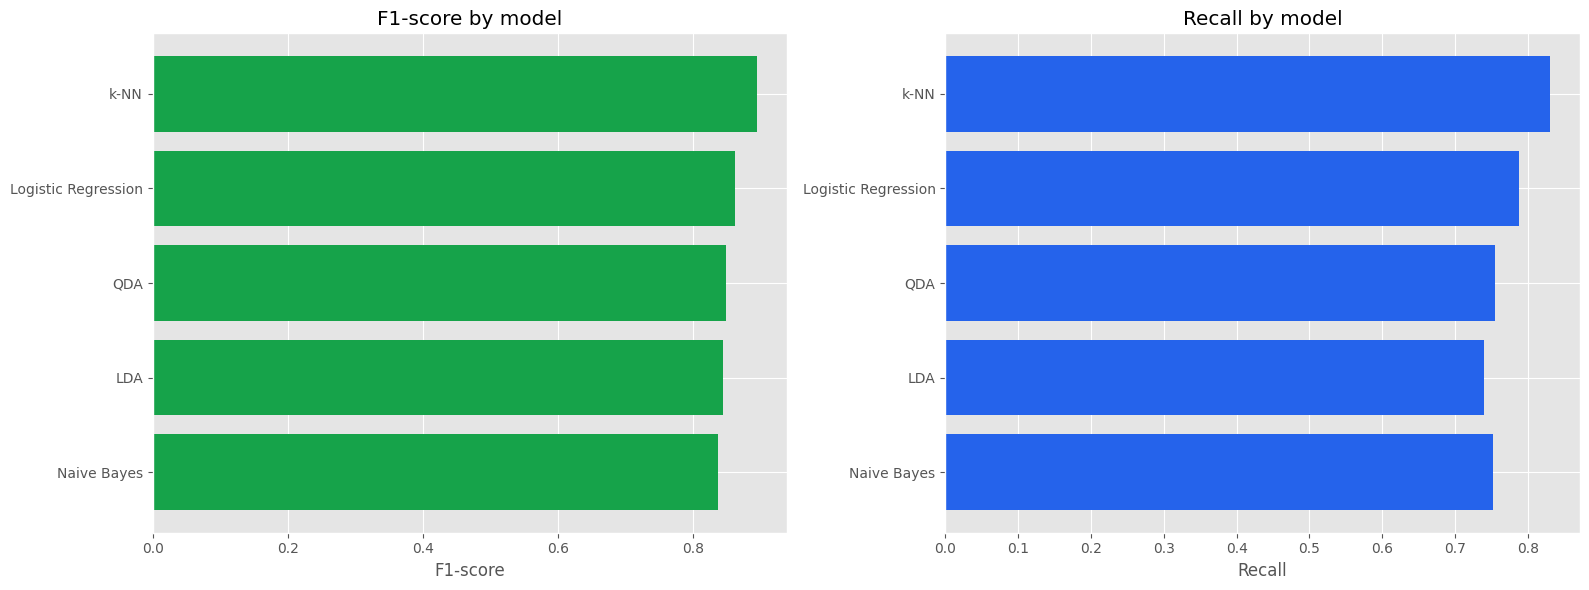

In [9]:
plot_df = results_df.sort_values('f1')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(plot_df['model'], plot_df['f1'], color='#16a34a')
axes[0].set_title('F1-score by model')
axes[0].set_xlabel('F1-score')

axes[1].barh(plot_df['model'], plot_df['recall'], color='#2563eb')
axes[1].set_title('Recall by model')
axes[1].set_xlabel('Recall')

plt.tight_layout()
plt.show()


### Paper-ready individual baseline plots

The next cell creates one figure for each supervised baseline model used in this study: Logistic Regression, Naive Bayes, LDA, QDA, and k-NN. Each figure uses the held-out test results already computed in Step 6 and includes the model's test-set confusion matrix.

These plots are intended for the paper because they show the full test metric profile for each classifier and the type of mistakes it makes: missed attacks versus benign windows flagged as attacks.


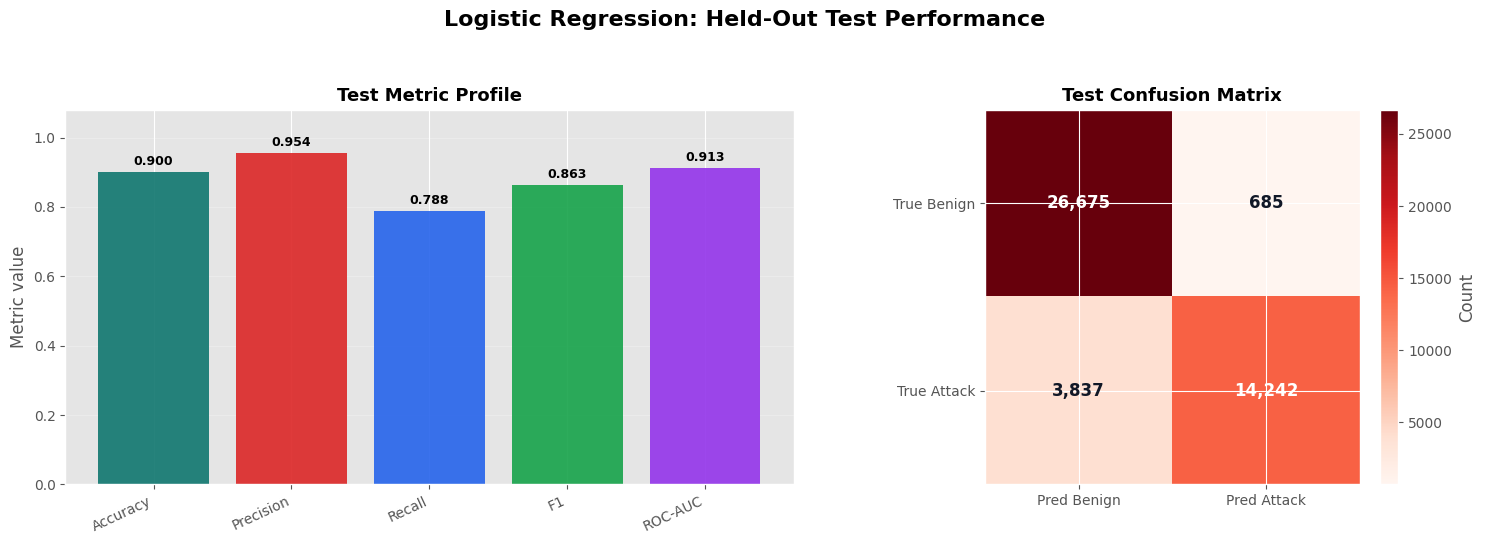

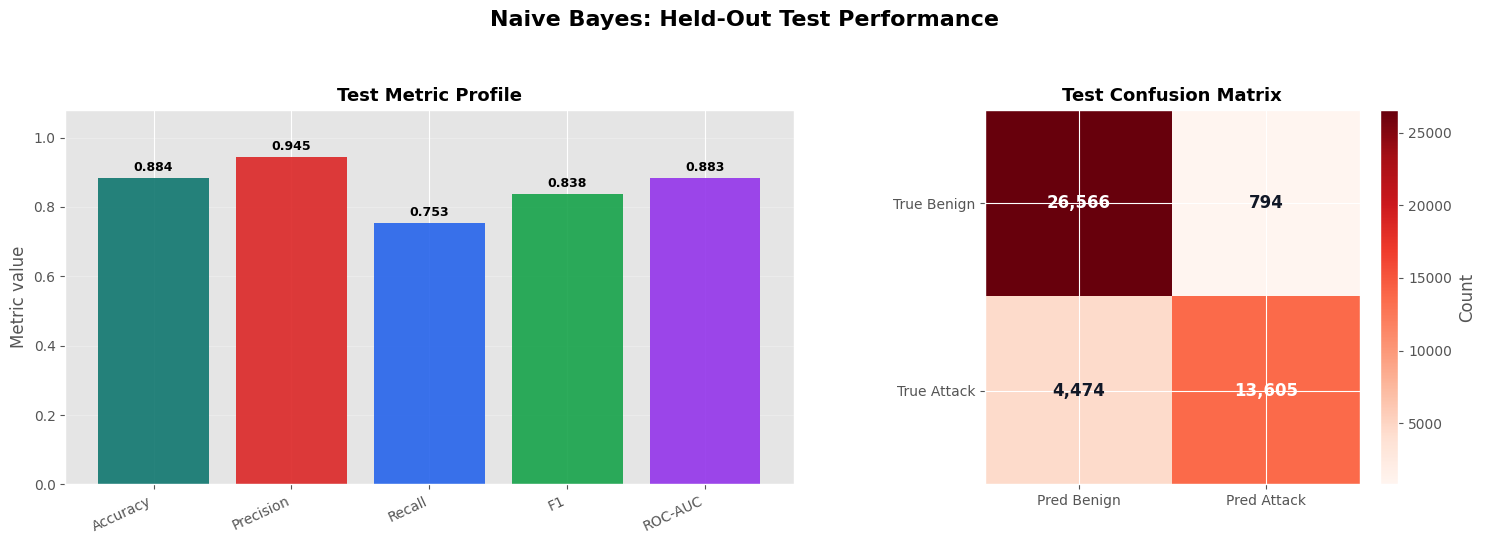

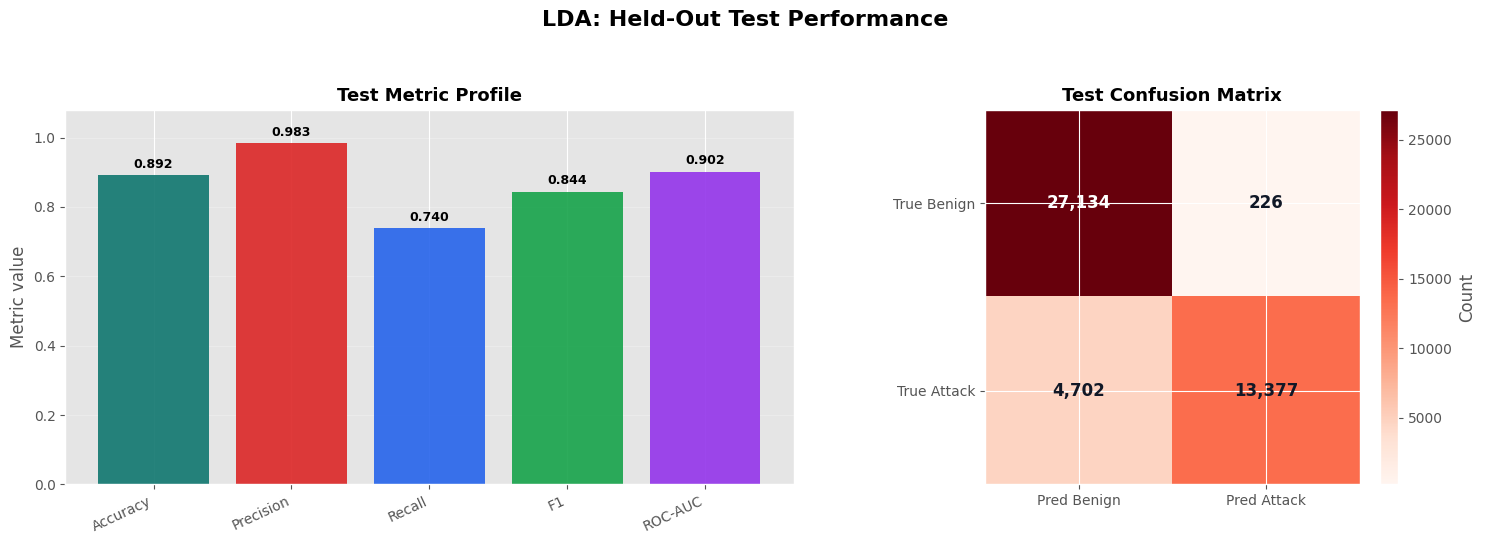

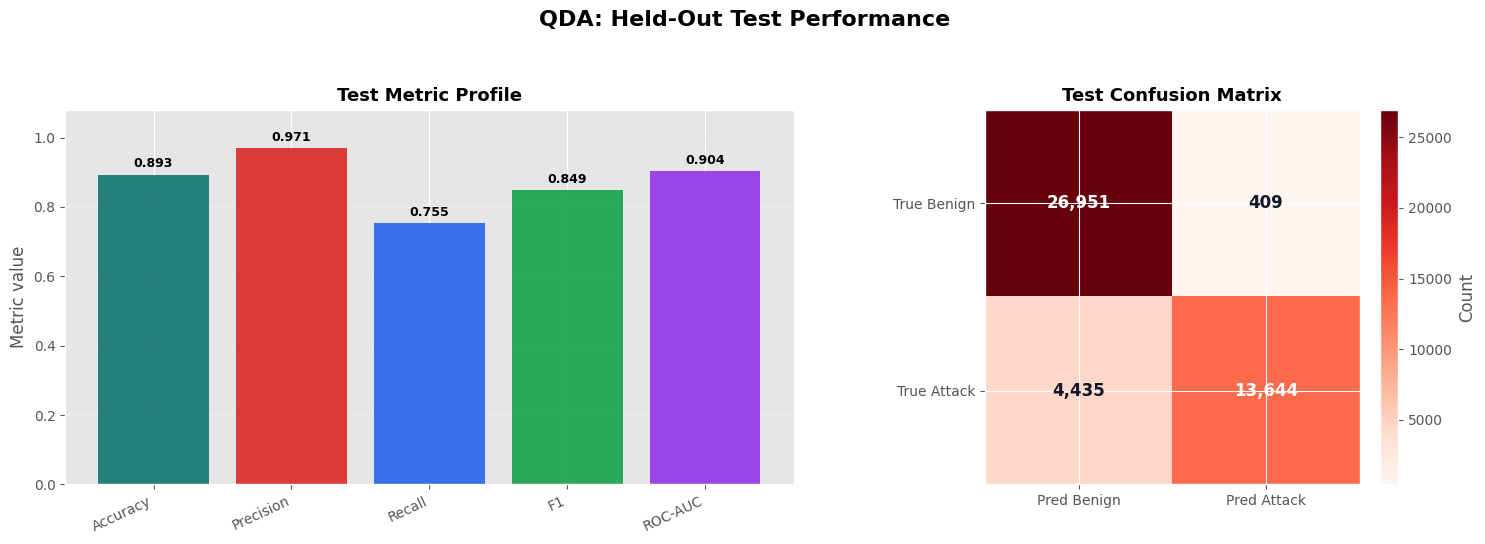

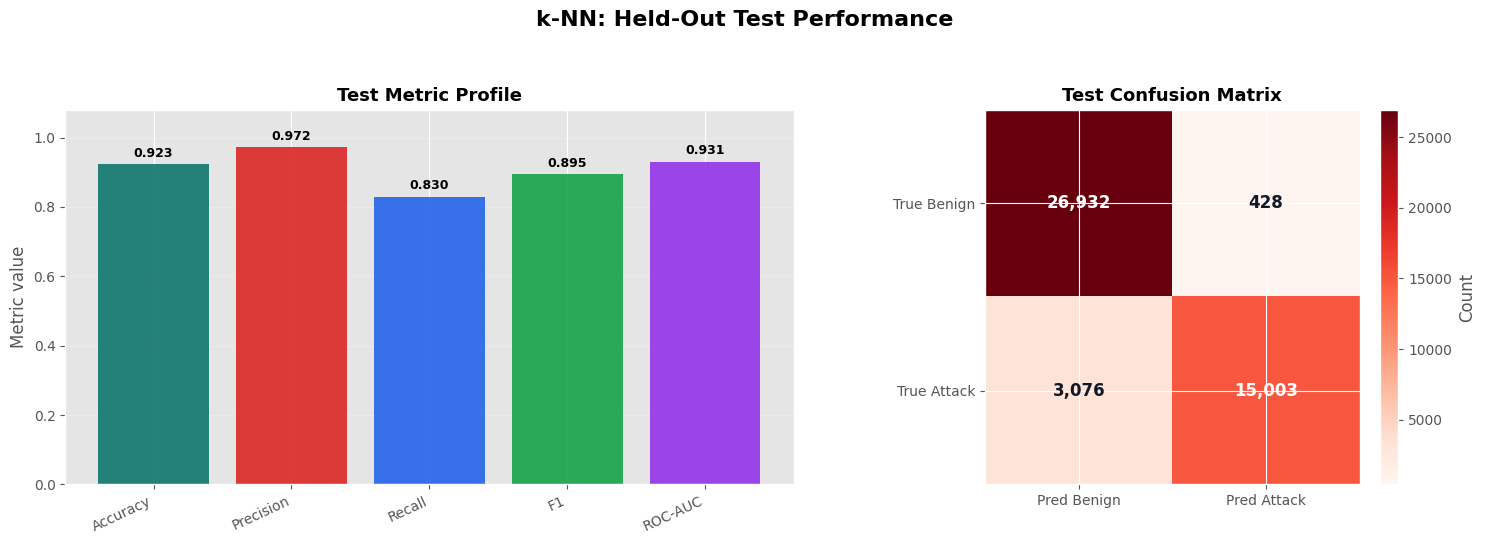

Table 2C. Test metrics used in the individual paper-ready baseline plots


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129
1,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826
2,LDA,0.8915,0.9834,0.7399,0.8445,0.9018
3,QDA,0.8934,0.9709,0.7547,0.8492,0.9037
4,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310


Saved paper-ready figures:
Logistic Regression: /Users/hectorcas13/Library/CloudStorage/Dropbox/University/PhD-Albany/CINF897-Independent_Study&Resarch/Graph GNN Comparisson/figures/baseline_logistic_regression_test_profile.png
Naive Bayes: /Users/hectorcas13/Library/CloudStorage/Dropbox/University/PhD-Albany/CINF897-Independent_Study&Resarch/Graph GNN Comparisson/figures/baseline_naive_bayes_test_profile.png
LDA: /Users/hectorcas13/Library/CloudStorage/Dropbox/University/PhD-Albany/CINF897-Independent_Study&Resarch/Graph GNN Comparisson/figures/baseline_lda_test_profile.png
QDA: /Users/hectorcas13/Library/CloudStorage/Dropbox/University/PhD-Albany/CINF897-Independent_Study&Resarch/Graph GNN Comparisson/figures/baseline_qda_test_profile.png
k-NN: /Users/hectorcas13/Library/CloudStorage/Dropbox/University/PhD-Albany/CINF897-Independent_Study&Resarch/Graph GNN Comparisson/figures/baseline_knn_test_profile.png


In [10]:
# Paper-ready individual test-set plots for each tabular baseline.
# These use the Step 6 classification outputs: results_df and conf_matrices.
# Each figure is saved to BASE_PATH / 'figures' and also displayed in the notebook.

figures_dir = BASE_PATH / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

paper_model_order = ['Logistic Regression', 'Naive Bayes', 'LDA', 'QDA', 'k-NN']
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

model_slug = {
    'Logistic Regression': 'logistic_regression',
    'Naive Bayes': 'naive_bayes',
    'LDA': 'lda',
    'QDA': 'qda',
    'k-NN': 'knn'
}

paper_plot_paths = {}
paper_test_metrics_df = results_df.set_index('model').loc[paper_model_order, metric_cols].reset_index()

for model_name in paper_model_order:
    metrics_row = results_df.set_index('model').loc[model_name, metric_cols]
    cm = conf_matrices[model_name]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1.45, 1]})
    fig.suptitle(f'{model_name}: Held-Out Test Performance', fontsize=16, fontweight='bold')

    values = metrics_row.values.astype(float)
    x = np.arange(len(metric_cols))
    bars = axes[0].bar(x, values, color=['#0f766e', '#dc2626', '#2563eb', '#16a34a', '#9333ea'], alpha=0.90)
    axes[0].set_title('Test Metric Profile', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Metric value')
    axes[0].set_ylim(0, 1.08)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metric_labels, rotation=25, ha='right')
    axes[0].grid(axis='y', alpha=0.25)
    axes[0].bar_label(bars, labels=[f'{v:.3f}' for v in values], padding=3, fontsize=9, fontweight='bold')

    im = axes[1].imshow(cm, cmap='Reds')
    axes[1].set_title('Test Confusion Matrix', fontsize=13, fontweight='bold')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['Pred Benign', 'Pred Attack'])
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(['True Benign', 'True Attack'])

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for row_idx in range(cm.shape[0]):
        for col_idx in range(cm.shape[1]):
            color = 'white' if cm[row_idx, col_idx] > threshold else '#111827'
            axes[1].text(col_idx, row_idx, f'{cm[row_idx, col_idx]:,}', ha='center', va='center', color=color, fontsize=12, fontweight='bold')

    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Count')

    filename = f'baseline_{model_slug[model_name]}_test_profile.png'
    output_path = figures_dir / filename
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    paper_plot_paths[model_name] = output_path
    plt.show()

print('Table 2C. Test metrics used in the individual paper-ready baseline plots')
display(paper_test_metrics_df.round(4))

print('Saved paper-ready figures:')
for model_name, path in paper_plot_paths.items():
    print(f'{model_name}: {path}')


## <div style="color:#166534;">7. Confusion matrix inspection</div>

A confusion matrix tells us four things:

- true benign predicted as benign,
- benign misclassified as attack,
- attacks missed as benign,
- attacks correctly detected.

This is one of the best ways to understand the practical behavior of each model.


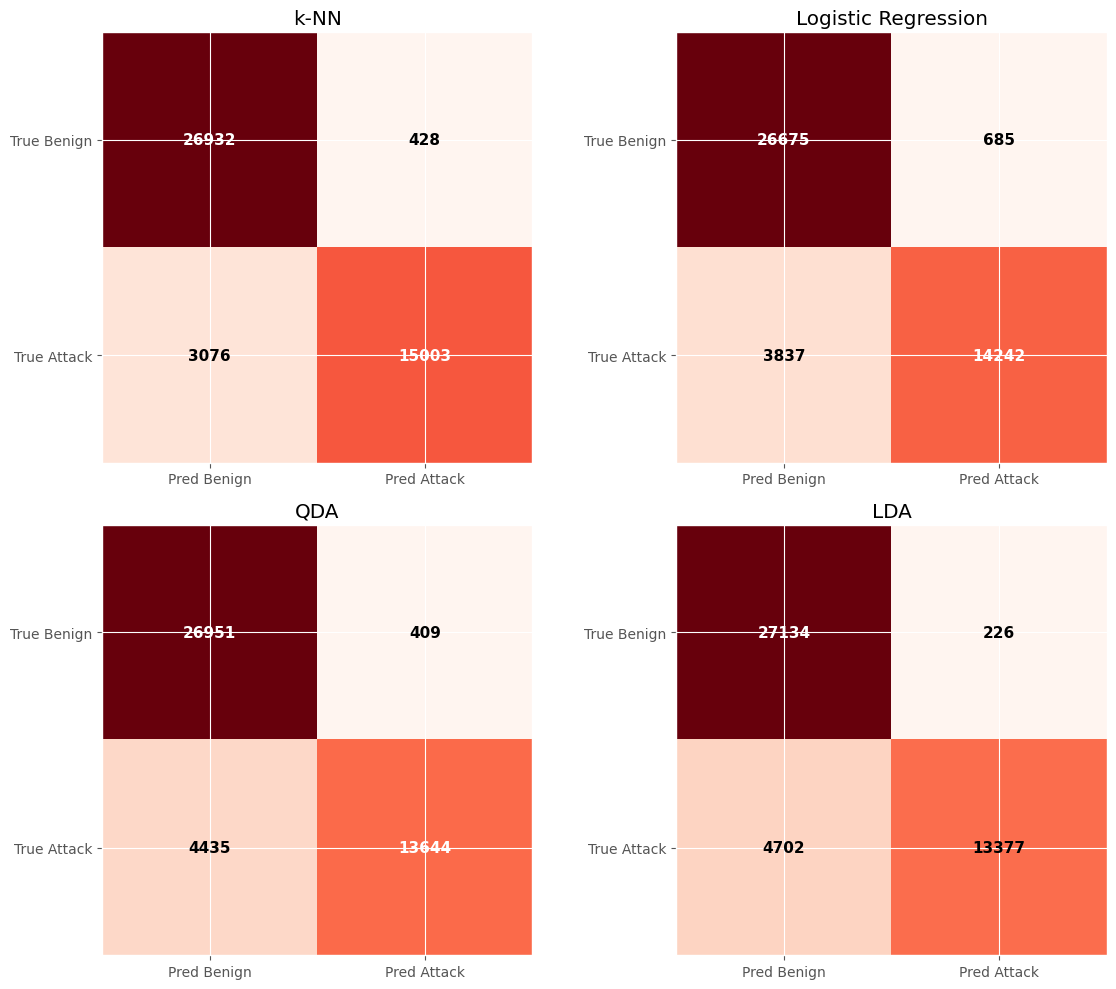

In [11]:
top_models = results_df.head(4)['model'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, model_name in zip(axes, top_models):
    cm = conf_matrices[model_name]
    im = ax.imshow(cm, cmap='Reds')
    ax.set_title(model_name)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Attack'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Attack'])

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=text_color, fontsize=11, fontweight='bold')

for ax in axes[len(top_models):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### Interpretation

`k-NN` is the most balanced model in these confusion matrices. It classifies benign traffic very well and also detects attack traffic better than the rest of the models. That is consistent with its top F1-score and recall, so in practice it is the strongest baseline at this point.

`Logistic Regression` also behaves well, but it is a little more conservative than `k-NN`. It still detects attacks reasonably well, but it misses more attack observations than `k-NN`. Even so, it remains one of the strongest and most reliable models in the notebook.

`QDA` shows strong precision, which means that when it predicts attack it is often correct, but its recall is lower than `k-NN` and `Logistic Regression`. In practical terms, it tends to miss more attacks, so it is less balanced overall even though it can be quite confident in the attack predictions it does make.

`LDA` is even more conservative. Its high precision suggests that it is careful when labeling something as attack, but the lower recall means it is leaving more attacks unflagged. That makes it weaker for intrusion detection, where missing attacks is a serious problem.

`Naive Bayes` is the weakest of the group. Its confusion matrix shows a less favorable balance between detecting attacks and maintaining strong overall classification. It does not collapse completely, but compared with the others it misses more attacks and gives the least competitive overall performance.

Taken together, these confusion matrices suggest that `k-NN` is currently the best classical model, `Logistic Regression` is the second strongest and most interpretable, `QDA` and `LDA` are more conservative and miss more attacks, and `Naive Bayes` is the weakest baseline in this notebook.


## <div style="color:#166534;">8. Consolidated baseline results</div>

At this point, we already have the baseline results we need from the supervised classifiers. These tables summarize the held-out test performance of the supervised classifiers.

### Table 1. Final baseline metrics on the held-out test set


In [12]:
all_results_df = results_df.copy()
all_results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']] = all_results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4)
all_results_df


,model,accuracy,precision,recall,f1,roc_auc
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018
4,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826


### Table 2. Ranking reference table for later comparison

This second table keeps the same baseline results in a ranking-friendly form so they can be compared more easily with the later cross-validation section.


In [13]:
ranking_reference_df = all_results_df.copy()
ranking_reference_df


,model,accuracy,precision,recall,f1,roc_auc
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018
4,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826


### Interpretation

This table is the final held-out-test ranking of the tabular classifiers. A strong model should combine high attack recall with high precision and F1-score, rather than relying on accuracy alone.


## <div style="color:#166534;">8B. Distribution diagnostics for LDA, QDA, and Naive Bayes</div>

LDA, QDA, and Naive Bayes are classical statistical classifiers. They are useful because they can return a probability-like score for the attack class, not only a final class label.

This section explains the distributions in two steps. First, we create a conceptual figure showing how to read distribution shape, overlap, and dispersion. Second, we plot the real predicted attack-probability distributions for `Naive Bayes`, `LDA`, and `QDA` on the held-out test set.

How to read the model distributions:

- values close to `0` mean the model believes the row is benign,
- values close to `1` mean the model believes the row is attack,
- strong separation means benign and attack curves are far apart,
- overlap means the model is uncertain and more mistakes are expected,
- wider curves or larger boxes mean more dispersion in the model scores.


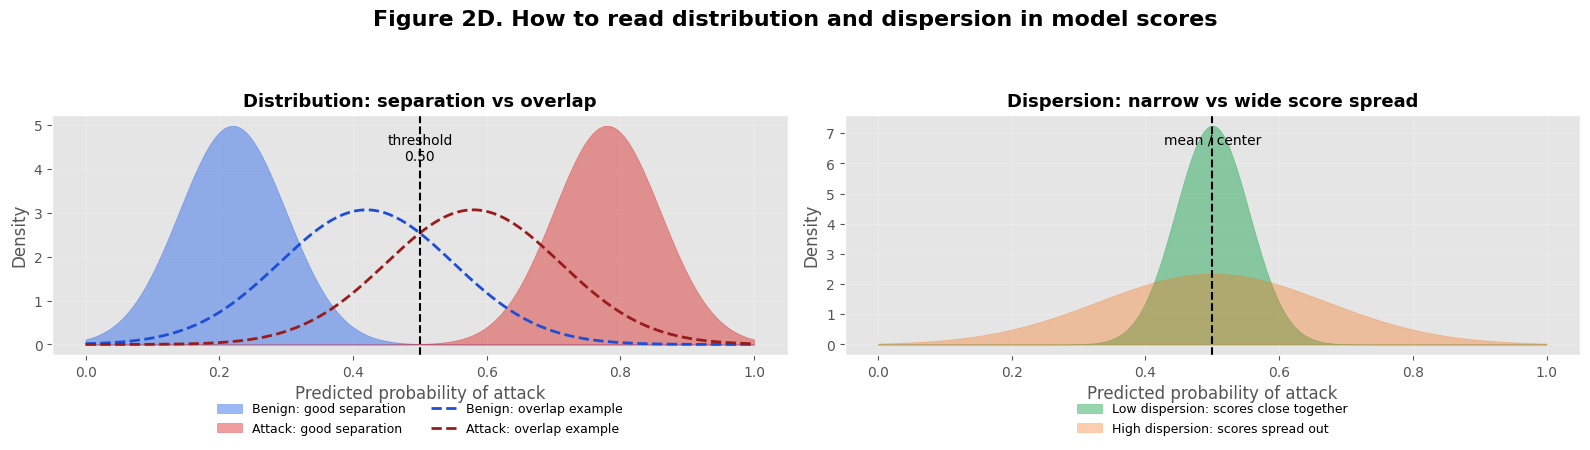

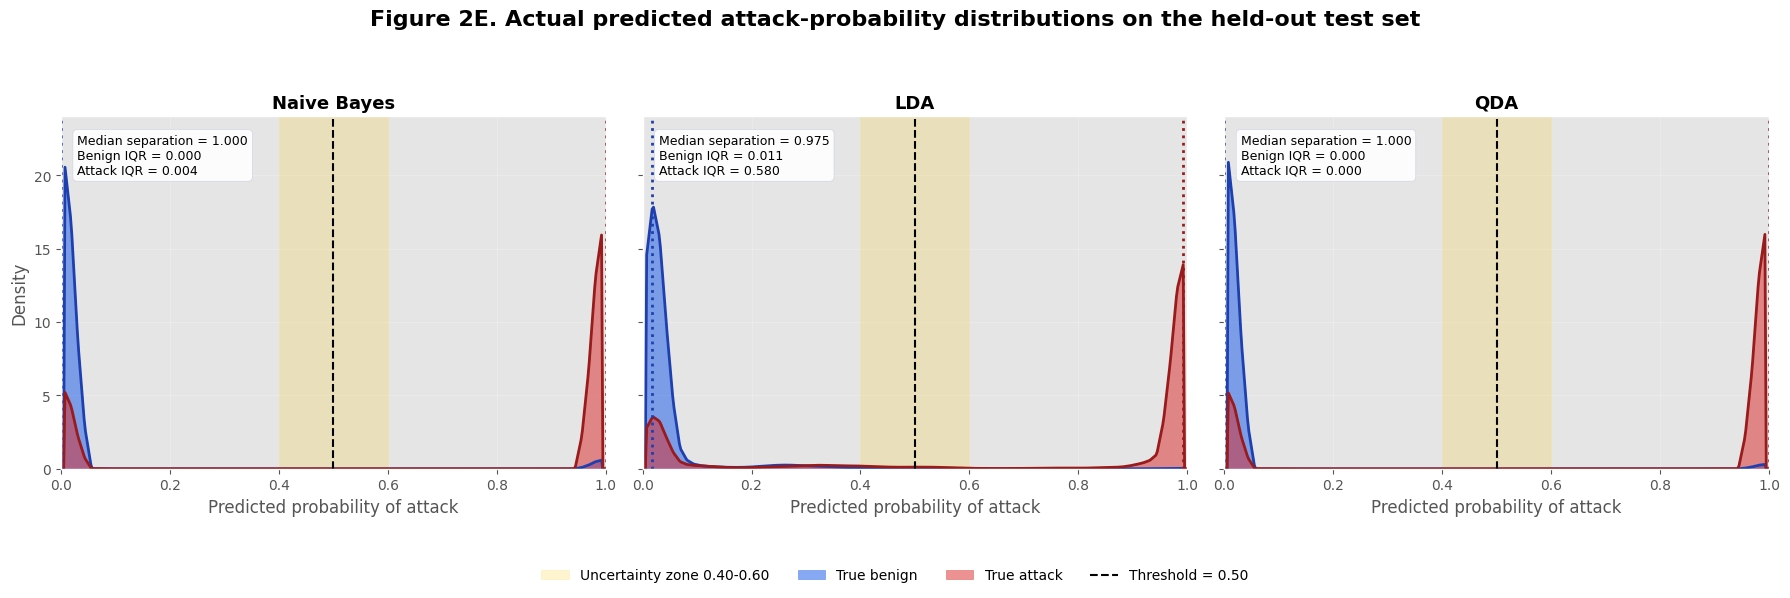

Table 2B. Distribution and dispersion diagnostics for LDA, QDA, and Naive Bayes


,model,median_prob_true_benign,median_prob_true_attack,median_separation_attack_minus_benign,iqr_true_benign,iqr_true_attack,benign_above_0.50_false_positive_rate,attack_below_0.50_false_negative_rate,uncertain_zone_0.40_to_0.60_pct
0,Naive Bayes,0.000,1.0000,1.000,0.0000,0.0042,0.0290,0.2475,0.0005
1,LDA,0.017,0.9919,0.975,0.0112,0.5798,0.0083,0.2601,0.0123
2,QDA,0.000,1.0000,1.000,0.0000,0.0000,0.0149,0.2453,0.0002


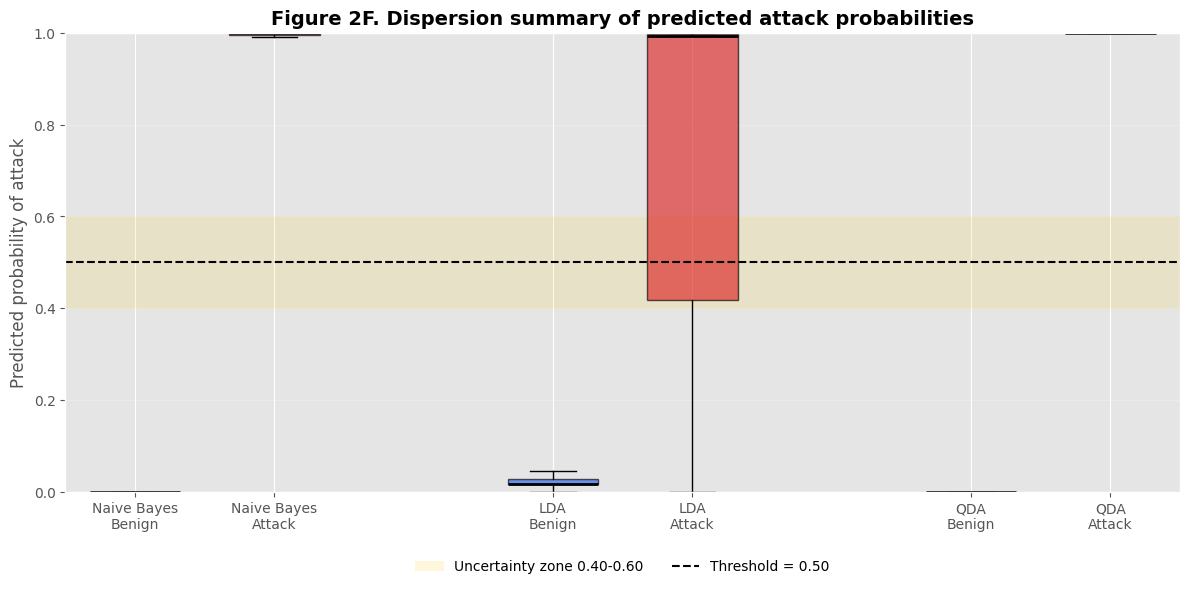

In [14]:
# Distribution diagnostics for LDA, QDA, and Naive Bayes.
distribution_models = ['Naive Bayes', 'LDA', 'QDA']

def normal_curve(x, mean, sd):
    return np.exp(-0.5 * ((x - mean) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))

def smooth_density(values, grid, bins=80, smooth_window=7):
    counts, edges = np.histogram(values, bins=bins, range=(0, 1), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    if smooth_window > 1:
        kernel_x = np.linspace(-2, 2, smooth_window)
        kernel = np.exp(-0.5 * kernel_x ** 2)
        kernel = kernel / kernel.sum()
        counts = np.convolve(counts, kernel, mode='same')
    return np.interp(grid, centers, counts, left=0, right=0)

# Figure 2D: conceptual guide, similar to the distribution/dispersion idea shown in class examples.
x = np.linspace(0, 1, 400)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Figure 2D. How to read distribution and dispersion in model scores', fontsize=16, fontweight='bold')

# Concept 1: separated vs overlapping distributions.
benign_good = normal_curve(x, 0.22, 0.08)
attack_good = normal_curve(x, 0.78, 0.08)
benign_overlap = normal_curve(x, 0.42, 0.13)
attack_overlap = normal_curve(x, 0.58, 0.13)

axes[0].fill_between(x, benign_good, color='#2563eb', alpha=0.45, label='Benign: good separation')
axes[0].fill_between(x, attack_good, color='#dc2626', alpha=0.45, label='Attack: good separation')
axes[0].plot(x, benign_overlap, color='#1d4ed8', linestyle='--', linewidth=2, label='Benign: overlap example')
axes[0].plot(x, attack_overlap, color='#991b1b', linestyle='--', linewidth=2, label='Attack: overlap example')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[0].text(0.5, axes[0].get_ylim()[1] * 0.92, 'threshold\n0.50', ha='center', va='top', fontsize=10)
axes[0].set_title('Distribution: separation vs overlap', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted probability of attack')
axes[0].set_ylabel('Density')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9, frameon=False)
axes[0].grid(alpha=0.20)

# Concept 2: low vs high dispersion.
low_disp = normal_curve(x, 0.5, 0.055)
high_disp = normal_curve(x, 0.5, 0.17)
axes[1].fill_between(x, low_disp, color='#16a34a', alpha=0.45, label='Low dispersion: scores close together')
axes[1].fill_between(x, high_disp, color='#f97316', alpha=0.35, label='High dispersion: scores spread out')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[1].text(0.5, axes[1].get_ylim()[1] * 0.92, 'mean / center', ha='center', va='top', fontsize=10)
axes[1].set_title('Dispersion: narrow vs wide score spread', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted probability of attack')
axes[1].set_ylabel('Density')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=9, frameon=False)
axes[1].grid(alpha=0.20)

plt.tight_layout(rect=[0, 0.12, 1, 0.92])
plt.show()

# Figure 2E: actual predicted attack-probability distributions for the three models.
grid = np.linspace(0, 1, 400)
diagnostic_rows = []
score_frames = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharey=True)
fig.suptitle('Figure 2E. Actual predicted attack-probability distributions on the held-out test set', fontsize=16, fontweight='bold')

for ax, model_name in zip(axes, distribution_models):
    model = scaled_models[model_name]
    attack_prob = model.predict_proba(X_test)[:, 1]
    benign_scores = attack_prob[y_test.values == 0]
    attack_scores = attack_prob[y_test.values == 1]

    benign_density = smooth_density(benign_scores, grid)
    attack_density = smooth_density(attack_scores, grid)
    benign_median = np.median(benign_scores)
    attack_median = np.median(attack_scores)
    benign_iqr = np.percentile(benign_scores, 75) - np.percentile(benign_scores, 25)
    attack_iqr = np.percentile(attack_scores, 75) - np.percentile(attack_scores, 25)

    ax.axvspan(0.4, 0.6, color='#facc15', alpha=0.20, label='Uncertainty zone 0.40-0.60')
    ax.fill_between(grid, benign_density, color='#2563eb', alpha=0.55, label='True benign')
    ax.fill_between(grid, attack_density, color='#dc2626', alpha=0.50, label='True attack')
    ax.plot(grid, benign_density, color='#1e40af', linewidth=2)
    ax.plot(grid, attack_density, color='#991b1b', linewidth=2)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.50')
    ax.axvline(benign_median, color='#1e40af', linestyle=':', linewidth=2)
    ax.axvline(attack_median, color='#991b1b', linestyle=':', linewidth=2)

    top_y = max(float(benign_density.max()), float(attack_density.max()))
    ax.annotate(
        f'Median separation = {attack_median - benign_median:.3f}\nBenign IQR = {benign_iqr:.3f}\nAttack IQR = {attack_iqr:.3f}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#cbd5e1', alpha=0.92)
    )

    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted probability of attack')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, top_y * 1.15 if top_y > 0 else 1)
    ax.grid(alpha=0.22)

    diagnostic_rows.append({
        'model': model_name,
        'median_prob_true_benign': benign_median,
        'median_prob_true_attack': attack_median,
        'median_separation_attack_minus_benign': attack_median - benign_median,
        'iqr_true_benign': benign_iqr,
        'iqr_true_attack': attack_iqr,
        'benign_above_0.50_false_positive_rate': np.mean(benign_scores >= 0.5),
        'attack_below_0.50_false_negative_rate': np.mean(attack_scores < 0.5),
        'uncertain_zone_0.40_to_0.60_pct': np.mean((attack_prob >= 0.4) & (attack_prob <= 0.6)),
    })

    score_frames.append(pd.DataFrame({
        'model': model_name,
        'true_class': np.where(y_test.values == 1, 'Attack', 'Benign'),
        'attack_probability': attack_prob,
    }))

axes[0].set_ylabel('Density')
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.show()

distribution_diagnostics_df = pd.DataFrame(diagnostic_rows)
print('Table 2B. Distribution and dispersion diagnostics for LDA, QDA, and Naive Bayes')
display(distribution_diagnostics_df.round(4))

score_distribution_df = pd.concat(score_frames, ignore_index=True)

# Figure 2F: compact dispersion summary using boxplots.
fig, ax = plt.subplots(figsize=(12, 6))
positions = []
box_data = []
box_colors = []
labels = []
for i, model_name in enumerate(distribution_models):
    base = i * 3
    for offset, true_class, color in [(0, 'Benign', '#2563eb'), (1, 'Attack', '#dc2626')]:
        values = score_distribution_df.loc[
            (score_distribution_df['model'] == model_name) &
            (score_distribution_df['true_class'] == true_class),
            'attack_probability'
        ].values
        positions.append(base + offset)
        box_data.append(values)
        box_colors.append(color)
        labels.append(f'{model_name}\n{true_class}')

box = ax.boxplot(box_data, positions=positions, widths=0.65, patch_artist=True, showfliers=False)
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.axhspan(0.4, 0.6, color='#facc15', alpha=0.14, label='Uncertainty zone 0.40-0.60')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.50')
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Predicted probability of attack')
ax.set_title('Figure 2F. Dispersion summary of predicted attack probabilities', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
plt.show()


### Interpretation

Figure 2D is a conceptual guide. It shows that distribution refers to the shape and location of the model scores, while dispersion refers to how spread out those scores are. In this project, the score is the predicted probability of attack. A good model should push benign windows toward low attack probability and attack windows toward high attack probability.

Figure 2E applies that idea to `Naive Bayes`, `LDA`, and `QDA`. The blue curve represents rows that are truly benign, and the red curve represents rows that are truly attacks. The dashed black line is the default decision threshold at `0.50`. Scores to the left of that line are classified as benign, and scores to the right are classified as attack. The yellow band between `0.40` and `0.60` is an uncertainty zone: observations in this region are close to the decision boundary and are more likely to be misclassified.

The dotted vertical lines show the median score for each class. If the blue median is close to `0` and the red median is close to `1`, the model is separating the two classes well. If the curves overlap around `0.50`, that means the model has difficulty distinguishing some benign and attack windows.

Figure 2F summarizes dispersion using boxplots. A narrow box means the model gives similar scores to many observations in that class. A wider box means the model scores are more spread out. For intrusion detection, the ideal pattern is a low blue box for benign traffic and a high red box for attack traffic, with little overlap between them.

For `Naive Bayes`, overlap can indicate that the independence assumption is too simple for this IIoT traffic dataset. For `LDA`, overlap suggests that a linear boundary may not capture all benign/attack differences. For `QDA`, better separation than LDA would suggest that benign and attack traffic have different covariance structures, while excessive dispersion may suggest sensitivity to noisy feature interactions.


## <div style="color:#166534;">9. Model interpretation and coefficient insight</div>

Interpreting the baseline models is important because it tells us what the classical approach is actually using to make decisions.

Since you want to focus on classical statistical classifiers, we use Logistic Regression coefficients as a simple and interpretable way to see which features push the prediction more strongly toward benign or attack.


In [15]:
logreg_pipeline = scaled_models['Logistic Regression']
logreg_model = logreg_pipeline.named_steps['model']

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': logreg_model.coef_[0],
    'abs_coefficient': np.abs(logreg_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False).head(20)

coef_df


,feature,coefficient,abs_coefficient
33,network_packet-size_max,-6.815483,6.815483
19,network_ip-length_max,6.781829,6.781829
38,network_packets_src_count,6.286369,6.286369
22,network_ips_all_count,5.516000,5.516000
44,network_ports_dst_count,4.675849,4.675849
55,network_tcp-flags_avg,-4.147003,4.147003
36,network_packets_all_count,4.100077,4.100077
49,network_tcp-flags-ack_count,4.081063,4.081063
57,network_tcp-flags_min,3.406363,3.406363
37,network_packets_dst_count,3.388543,3.388543


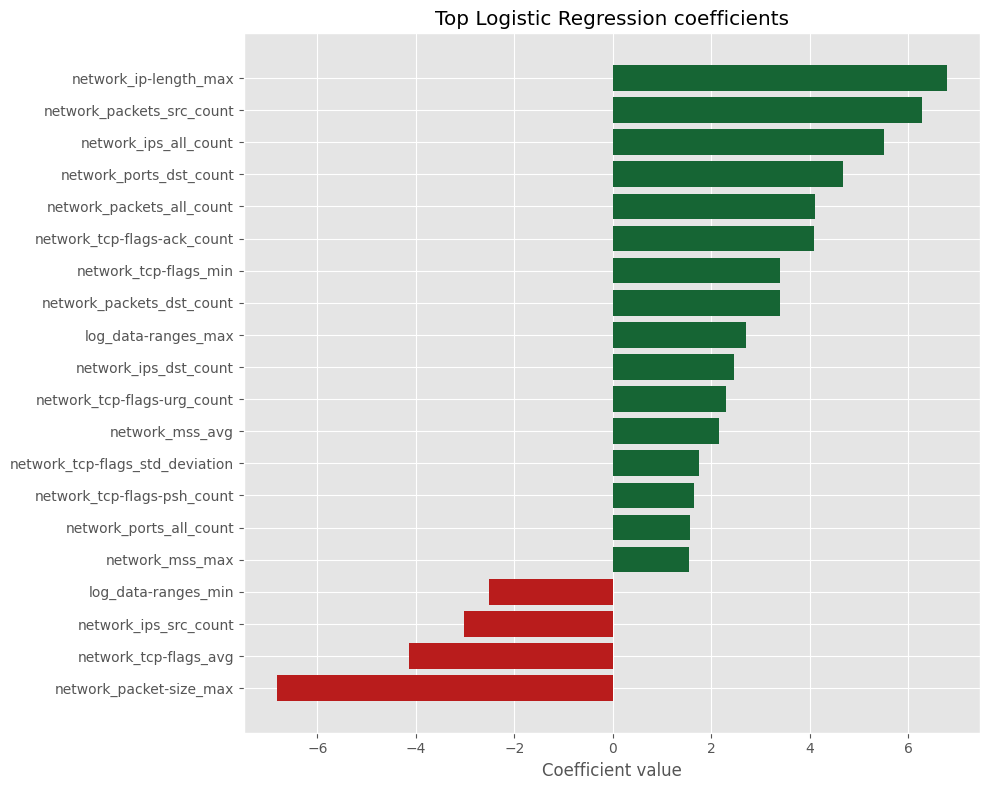

In [16]:
plot_coef = coef_df.sort_values('coefficient')
colors = ['#b91c1c' if c < 0 else '#166534' for c in plot_coef['coefficient']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_coef['feature'], plot_coef['coefficient'], color=colors)
ax.set_title('Top Logistic Regression coefficients')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()


### Interpretation

This coefficient chart explains how the numeric predictors influence Logistic Regression. Positive coefficients push a prediction toward the attack class, negative coefficients push it toward benign behavior, and larger absolute values indicate stronger effects on the model decision. Coefficients should be interpreted together with feature scaling and the other evaluation results.


## <div style="color:#166534;">10. 10-Fold Cross-Validation Check</div>

The earlier sections already evaluated the models on a **held-out test set**.

This section adds a second type of evaluation: `10-fold stratified cross-validation` on the training data.

So the logic is:

- **test-set evaluation** = performance on one held-out unseen split
- **cross-validation** = robustness check across many folds of the training data

A single train/test split is useful, but it can still be influenced by how the data happened to be divided. To make the evaluation more robust, we now run a `10-fold stratified cross-validation` on the training data.

### What this does

- It splits the training data into 10 folds.
- It trains the model 10 times.
- Each time, 9 folds are used for training and 1 fold is used for validation.
- At the end, we average the results across the 10 runs.

This gives us a more stable view of model performance and lets us check whether the ranking of models changes compared with the earlier single-split evaluation.


In [17]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_rows = []
for model_name, model in scaled_models.items():
    cv_scores = cross_validate(
        model,
        X_train_model,
        y_train_model,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_rows.append({
        'model': model_name,
        'cv_accuracy_mean': np.mean(cv_scores['test_accuracy']),
        'cv_accuracy_std': np.std(cv_scores['test_accuracy']),
        'cv_precision_mean': np.mean(cv_scores['test_precision']),
        'cv_precision_std': np.std(cv_scores['test_precision']),
        'cv_recall_mean': np.mean(cv_scores['test_recall']),
        'cv_recall_std': np.std(cv_scores['test_recall']),
        'cv_f1_mean': np.mean(cv_scores['test_f1']),
        'cv_f1_std': np.std(cv_scores['test_f1']),
        'cv_roc_auc_mean': np.mean(cv_scores['test_roc_auc']),
        'cv_roc_auc_std': np.std(cv_scores['test_roc_auc'])
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
print('Table 3. 10-fold cross-validation mean performance by model')
cv_results_df.round(4)


Table 3. 10-fold cross-validation mean performance by model


,model,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std
0,k-NN,0.9212,0.0019,0.9726,0.0012,0.8253,0.0048,0.8929,0.0029,0.9308,0.0053
1,Logistic Regression,0.8990,0.0019,0.9563,0.0022,0.7818,0.0043,0.8603,0.0028,0.9104,0.0025
2,QDA,0.8905,0.0017,0.9722,0.0024,0.7460,0.0042,0.8442,0.0027,0.9024,0.0030
3,LDA,0.8892,0.0019,0.9853,0.0017,0.7324,0.0048,0.8402,0.0031,0.8984,0.0026
4,Naive Bayes,0.8826,0.0023,0.9469,0.0033,0.7467,0.0043,0.8350,0.0034,0.8791,0.0035


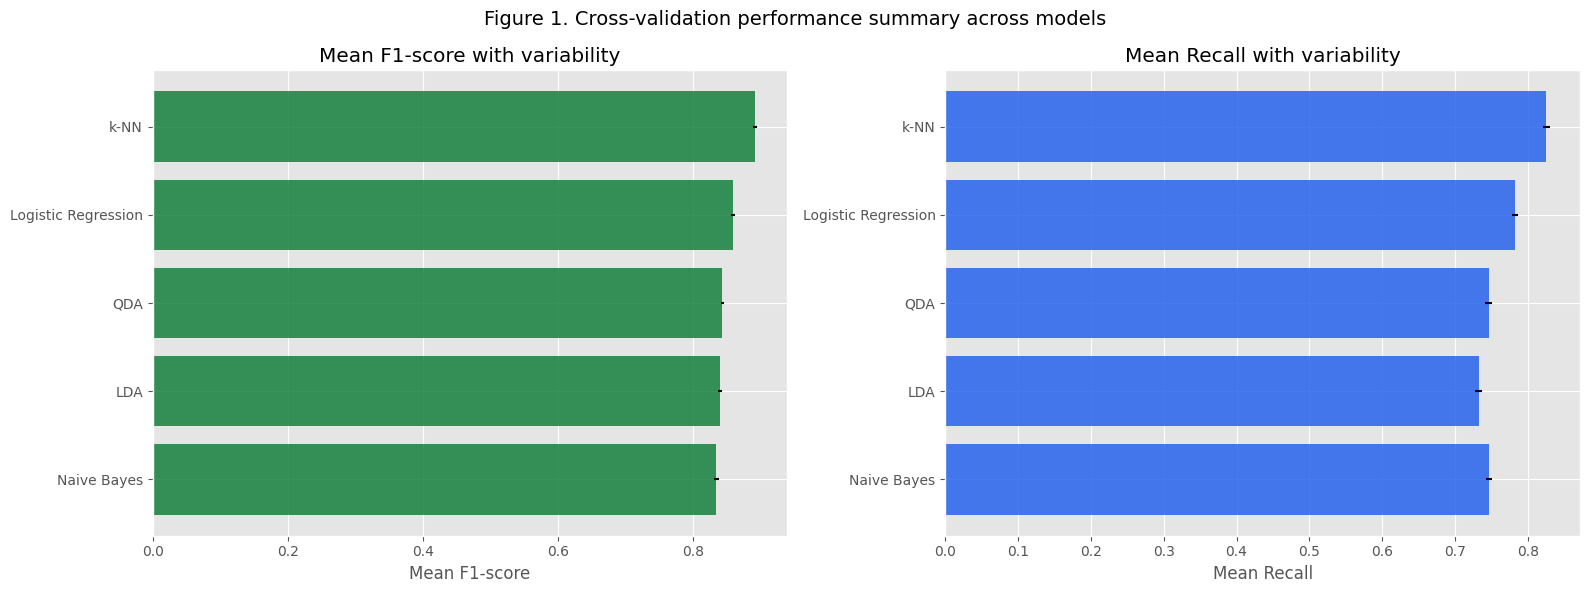

In [18]:
cv_plot_df = cv_results_df.sort_values('cv_f1_mean')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 1. Cross-validation performance summary across models', fontsize=14)

axes[0].barh(cv_plot_df['model'], cv_plot_df['cv_f1_mean'], xerr=cv_plot_df['cv_f1_std'], color='#15803d', alpha=0.85)
axes[0].set_title('Mean F1-score with variability')
axes[0].set_xlabel('Mean F1-score')

axes[1].barh(cv_plot_df['model'], cv_plot_df['cv_recall_mean'], xerr=cv_plot_df['cv_recall_std'], color='#2563eb', alpha=0.85)
axes[1].set_title('Mean Recall with variability')
axes[1].set_xlabel('Mean Recall')

plt.tight_layout()
plt.show()


In [19]:
ranking_comparison_df = (
    results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
    .merge(
        cv_results_df[['model', 'cv_accuracy_mean', 'cv_precision_mean', 'cv_recall_mean', 'cv_f1_mean', 'cv_roc_auc_mean']],
        on='model',
        how='left'
    )
)
ranking_comparison_df['holdout_rank_by_f1'] = ranking_comparison_df['f1'].rank(ascending=False, method='dense').astype(int)
ranking_comparison_df['cv_rank_by_f1'] = ranking_comparison_df['cv_f1_mean'].rank(ascending=False, method='dense').astype(int)
ranking_comparison_df = ranking_comparison_df.sort_values('cv_rank_by_f1').reset_index(drop=True)
print('Table 4. Ranking comparison between holdout test results and 10-fold cross-validation')
ranking_comparison_df.round(4)


Table 4. Ranking comparison between holdout test results and 10-fold cross-validation


,model,accuracy,precision,recall,f1,roc_auc,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,holdout_rank_by_f1,cv_rank_by_f1
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310,0.9212,0.9726,0.8253,0.8929,0.9308,1,1
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129,0.8990,0.9563,0.7818,0.8603,0.9104,2,2
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037,0.8905,0.9722,0.7460,0.8442,0.9024,3,3
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018,0.8892,0.9853,0.7324,0.8402,0.8984,4,4
4,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826,0.8826,0.9469,0.7467,0.8350,0.8791,5,5


### Interpretation

This section is designed to help you answer a very important question: do the models still look good when we evaluate them more robustly across multiple folds, or was the earlier ranking too dependent on one split?

### How to read the table

- `cv_*_mean` tells you the average metric across the 10 folds.
- `cv_*_std` tells you how much the result varies from fold to fold.
- Lower standard deviation means the model is more stable.
- Higher mean F1 and recall usually matter most for your intrusion detection task.

### How to read the plots

- The left plot shows the average `F1-score` of each model across the 10 folds.
- The right plot shows the average `Recall` across the 10 folds.
- The error bars show variability. Smaller error bars usually mean the model behaves more consistently.

### What to look for

1. Which model has the highest average F1-score?
2. Which model has the highest average recall?
3. Which model has small error bars and therefore looks more stable?
4. Did the ranking change compared with the earlier single train/test split?

### Why this matters

If a model was best in the earlier ranking and is still best here, that strengthens confidence in the result.
If the ranking changes, then the earlier split may have favored one model unfairly, and the cross-validation result becomes more trustworthy.

For this study, this section identifies the most stable classical classifier across multiple data partitions.


In [20]:
best_holdout_model = results_df.sort_values('f1', ascending=False).iloc[0]
best_cv_model = cv_results_df.sort_values('cv_f1_mean', ascending=False).iloc[0]
worst_cv_model = cv_results_df.sort_values('cv_f1_mean', ascending=True).iloc[0]
rank_changed = not (best_holdout_model['model'] == best_cv_model['model'])

summary_lines = []
summary_lines.append(f"Best model on the original holdout split by F1-score: {best_holdout_model['model']} (F1 = {best_holdout_model['f1']:.4f}).")
summary_lines.append(f"Best model under 10-fold cross-validation by mean F1-score: {best_cv_model['model']} (mean F1 = {best_cv_model['cv_f1_mean']:.4f}, std = {best_cv_model['cv_f1_std']:.4f}).")
summary_lines.append(f"Worst model under 10-fold cross-validation by mean F1-score: {worst_cv_model['model']} (mean F1 = {worst_cv_model['cv_f1_mean']:.4f}).")
if rank_changed:
    summary_lines.append('The model ranking changed after cross-validation, which means the single train/test split was not the whole story and the CV ranking should be treated as the more robust reference.')
else:
    summary_lines.append('The top model stayed the same after cross-validation, which strengthens confidence that the ranking is stable.')
summary_lines.append('For intrusion detection, give special attention to mean recall as well as mean F1-score, because a model that misses attacks can be risky even if its overall score looks good.')

print(*summary_lines, sep='\n')


Best model on the original holdout split by F1-score: k-NN (F1 = 0.8954).
Best model under 10-fold cross-validation by mean F1-score: k-NN (mean F1 = 0.8929, std = 0.0029).
Worst model under 10-fold cross-validation by mean F1-score: Naive Bayes (mean F1 = 0.8350).
The top model stayed the same after cross-validation, which strengthens confidence that the ranking is stable.
For intrusion detection, give special attention to mean recall as well as mean F1-score, because a model that misses attacks can be risky even if its overall score looks good.


## <div style="color:#166534;">11. General Takeaway</div>

This section summarizes the main lessons from the whole baseline notebook so far. The goal is not only to report model scores, but also to understand what the data and the models are telling us about attack detection.


### Table 5. Training vs test performance by model

This table compares how each model performs on the data it was trained on versus the unseen test data. It helps reveal whether a model generalizes well or whether it may be overfitting.


In [21]:
train_test_rows = []

for model_name, model in scaled_models.items():
    y_train_pred = model.predict(X_train_model)
    y_test_pred = model.predict(X_test)

    train_score = get_model_scores(model, X_train_model)
    test_score = get_model_scores(model, X_test)

    train_test_rows.append({
        'model': model_name,
        'train_accuracy': accuracy_score(y_train_model, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'train_precision': precision_score(y_train_model, y_train_pred, zero_division=0),
        'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
        'train_recall': recall_score(y_train_model, y_train_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred, zero_division=0),
        'train_f1': f1_score(y_train_model, y_train_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
        'train_roc_auc': roc_auc_score(y_train_model, train_score) if train_score is not None else np.nan,
        'test_roc_auc': roc_auc_score(y_test, test_score) if test_score is not None else np.nan,
    })

train_test_comparison_df = pd.DataFrame(train_test_rows)
train_test_comparison_df['f1_gap_train_minus_test'] = train_test_comparison_df['train_f1'] - train_test_comparison_df['test_f1']
train_test_comparison_df = train_test_comparison_df.sort_values('test_f1', ascending=False).reset_index(drop=True)
train_test_comparison_df.round(4)


,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,f1_gap_train_minus_test
0,k-NN,0.9298,0.9229,0.9830,0.9723,0.8380,0.8299,0.9047,0.8954,0.9471,0.9310,0.0093
1,Logistic Regression,0.8993,0.9005,0.9569,0.9541,0.7821,0.7878,0.8607,0.8630,0.9106,0.9129,-0.0023
2,QDA,0.8906,0.8934,0.9723,0.9709,0.7462,0.7547,0.8444,0.8492,0.9003,0.9037,-0.0049
3,LDA,0.8892,0.8915,0.9854,0.9834,0.7324,0.7399,0.8403,0.8445,0.8986,0.9018,-0.0042
4,Naive Bayes,0.8825,0.8841,0.9470,0.9449,0.7465,0.7525,0.8349,0.8378,0.8791,0.8826,-0.0029


### Figure 2. Training vs test comparison by model

These plots help compare how each model performs on the training data versus the unseen test data. Large gaps can be a sign of overfitting, while smaller gaps suggest better generalization.


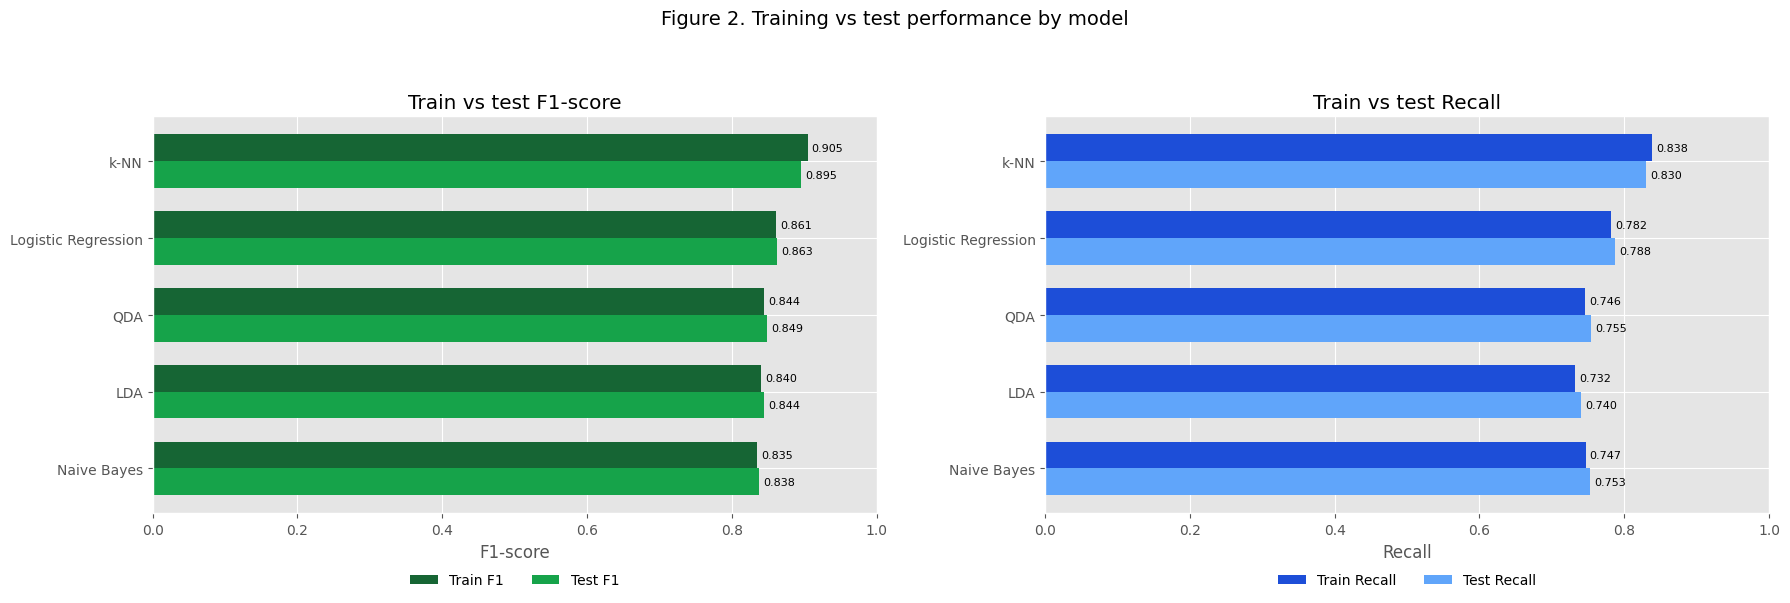

In [22]:
plot_df = train_test_comparison_df.sort_values('test_f1', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Figure 2. Training vs test performance by model', fontsize=14)

x = np.arange(len(plot_df['model']))
width = 0.35

train_f1_bars = axes[0].barh(x + width/2, plot_df['train_f1'], height=width, label='Train F1', color='#166534')
test_f1_bars = axes[0].barh(x - width/2, plot_df['test_f1'], height=width, label='Test F1', color='#16a34a')
axes[0].set_yticks(x)
axes[0].set_yticklabels(plot_df['model'])
axes[0].set_xlabel('F1-score')
axes[0].set_title('Train vs test F1-score')
axes[0].set_xlim(0, 1.0)
axes[0].bar_label(train_f1_bars, labels=[f"{v:.3f}" for v in plot_df['train_f1']], padding=3, fontsize=8)
axes[0].bar_label(test_f1_bars, labels=[f"{v:.3f}" for v in plot_df['test_f1']], padding=3, fontsize=8)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

train_recall_bars = axes[1].barh(x + width/2, plot_df['train_recall'], height=width, label='Train Recall', color='#1d4ed8')
test_recall_bars = axes[1].barh(x - width/2, plot_df['test_recall'], height=width, label='Test Recall', color='#60a5fa')
axes[1].set_yticks(x)
axes[1].set_yticklabels(plot_df['model'])
axes[1].set_xlabel('Recall')
axes[1].set_title('Train vs test Recall')
axes[1].set_xlim(0, 1.0)
axes[1].bar_label(train_recall_bars, labels=[f"{v:.3f}" for v in plot_df['train_recall']], padding=3, fontsize=8)
axes[1].bar_label(test_recall_bars, labels=[f"{v:.3f}" for v in plot_df['test_recall']], padding=3, fontsize=8)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0.10, 1, 0.93])
plt.show()


In [23]:
top_attack_features = coef_df[coef_df['coefficient'] > 0].sort_values('coefficient', ascending=False).head(10)
top_benign_features = coef_df[coef_df['coefficient'] < 0].sort_values('coefficient', ascending=True).head(10)

device_attack_counts = attack_df['device_name'].value_counts().head(10).rename_axis('device_name').reset_index(name='attack_rows')
attack_subtype_counts = attack_df['label3'].value_counts().head(10).rename_axis('label3').reset_index(name='rows')

best_two_models = cv_results_df.sort_values('cv_f1_mean', ascending=False).head(2)[['model', 'cv_f1_mean', 'cv_recall_mean', 'cv_precision_mean']]
worst_two_models = cv_results_df.sort_values('cv_f1_mean', ascending=True).head(2)[['model', 'cv_f1_mean', 'cv_recall_mean', 'cv_precision_mean']]

print('Top features pushing prediction toward attack:')
display(top_attack_features[['feature', 'coefficient']].round(4))
print('Top features pushing prediction toward benign:')
display(top_benign_features[['feature', 'coefficient']].round(4))
print('Two best models by cross-validated mean F1:')
display(best_two_models.round(4))
print('Two weakest models by cross-validated mean F1:')
display(worst_two_models.round(4))
print('Most attacked devices by number of attack rows:')
display(device_attack_counts)
print('Most common attack subtypes:')
display(attack_subtype_counts)


Top features pushing prediction toward attack:


,feature,coefficient
19,network_ip-length_max,6.7818
38,network_packets_src_count,6.2864
22,network_ips_all_count,5.5160
44,network_ports_dst_count,4.6758
36,network_packets_all_count,4.1001
49,network_tcp-flags-ack_count,4.0811
57,network_tcp-flags_min,3.4064
37,network_packets_dst_count,3.3885
1,log_data-ranges_max,2.6976
23,network_ips_dst_count,2.4646


Top features pushing prediction toward benign:


,feature,coefficient
33,network_packet-size_max,-6.8155
55,network_tcp-flags_avg,-4.1470
24,network_ips_src_count,-3.0295
2,log_data-ranges_min,-2.5183


Two best models by cross-validated mean F1:


...

,model,cv_f1_mean,cv_recall_mean,cv_precision_mean
4,Naive Bayes,0.8350,0.7467,0.9469
3,LDA,0.8402,0.7324,0.9853


Most attacked devices by number of attack rows:


,device_name,attack_rows
0,mqtt-broker,9000
1,edge1,8870
2,router,4053
3,ap,3276
4,wisenet-camera,3127
5,steam-sensor,2934
6,yi-camera,2848
7,motion-sensor,2837
8,weather-sensor,2835
9,accelerometer-sensor,2568


Most common attack subtypes:


,label3,rows
0,arp-spoofing,4196
1,mirai-udp-flood,4010
2,os-scan,3968
3,host-disc-tcp-ack-ping,3947
4,vuln-scan,3944
5,host-disc-tcp-syn-ping,3932
6,port-scan,3924
7,host-disc-tcp-syn-stealth,3918
8,host-disc-arp-ping,3911
9,host-disc-udp-ping,3894


### Interpretation

Based on the saved results, `k-NN` is the strongest classical classifier. It achieved the best held-out-test result and remained strongest under 10-fold cross-validation, which provides stronger evidence than a single favorable split. Its recall is especially relevant because it captures a larger proportion of attack windows.

`Logistic Regression` is the second key classifier. Although it does not outperform `k-NN`, its coefficients make the direction and relative contribution of predictors easier to explain. `Naive Bayes` has the weakest F1-score in the current holdout and cross-validation results, suggesting that its conditional-independence assumptions do not represent this traffic as effectively.

The training-versus-test comparison helps identify overfitting. Small performance gaps suggest better generalization, whereas a substantially stronger training score can indicate that a model has learned patterns that do not transfer as well to unseen windows.

The Logistic Regression coefficients indicate that packet intensity, IP diversity, destination-port activity, packet length, and TCP-flag behavior contribute strongly to attack prediction. These findings should be interpreted as associations within this dataset, not as universal causal indicators of malicious traffic.


## <div style="color:#166534;">11B. Unified baseline evaluation: train, test, and 10-fold CV</div>

This section puts the supervised tabular evaluation views in one place:

- **Training performance** shows how well the model fits the data it learned from.
- **Held-out test performance** shows how well the model performs on unseen data.
- **10-fold cross-validation** checks whether the result is stable across multiple training/validation splits.

Table 5B gives the full wide comparison. Table 5B-2 reorganizes only the tabular train/test metrics into a paper-friendly long format, where each model has one row for training and one row for testing. The combined confusion-matrix figure below the table focuses on the held-out test set, because that is the clearest view of how each model behaves on unseen data.


In [24]:
# Unified baseline table: train vs held-out test vs 10-fold cross-validation.

baseline_unified_df = (
    train_test_comparison_df[[
        'model',
        'train_accuracy', 'train_precision', 'train_recall', 'train_f1', 'train_roc_auc',
        'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc',
        'f1_gap_train_minus_test'
    ]]
    .merge(
        cv_results_df[[
            'model',
            'cv_accuracy_mean', 'cv_accuracy_std',
            'cv_precision_mean', 'cv_precision_std',
            'cv_recall_mean', 'cv_recall_std',
            'cv_f1_mean', 'cv_f1_std',
            'cv_roc_auc_mean', 'cv_roc_auc_std'
        ]],
        on='model',
        how='left'
    )
)

baseline_unified_df['test_rank_by_f1'] = baseline_unified_df['test_f1'].rank(ascending=False, method='dense').astype(int)
baseline_unified_df['cv_rank_by_f1'] = baseline_unified_df['cv_f1_mean'].rank(ascending=False, method='dense').astype(int)
baseline_unified_df = baseline_unified_df.sort_values(['test_rank_by_f1', 'cv_rank_by_f1']).reset_index(drop=True)

print('Table 5B. Unified baseline comparison: training, held-out test, and 10-fold cross-validation')
display(baseline_unified_df.round(4))


Table 5B. Unified baseline comparison: training, held-out test, and 10-fold cross-validation


,model,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,f1_gap_train_minus_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_rank_by_f1,cv_rank_by_f1
0,k-NN,0.9298,0.9830,0.8380,0.9047,0.9471,0.9229,0.9723,0.8299,0.8954,0.9310,0.0093,0.9212,0.0019,0.9726,0.0012,0.8253,0.0048,0.8929,0.0029,0.9308,0.0053,1,1
1,Logistic Regression,0.8993,0.9569,0.7821,0.8607,0.9106,0.9005,0.9541,0.7878,0.8630,0.9129,-0.0023,0.8990,0.0019,0.9563,0.0022,0.7818,0.0043,0.8603,0.0028,0.9104,0.0025,2,2
2,QDA,0.8906,0.9723,0.7462,0.8444,0.9003,0.8934,0.9709,0.7547,0.8492,0.9037,-0.0049,0.8905,0.0017,0.9722,0.0024,0.7460,0.0042,0.8442,0.0027,0.9024,0.0030,3,3
3,LDA,0.8892,0.9854,0.7324,0.8403,0.8986,0.8915,0.9834,0.7399,0.8445,0.9018,-0.0042,0.8892,0.0019,0.9853,0.0017,0.7324,0.0048,0.8402,0.0031,0.8984,0.0026,4,4
4,Naive Bayes,0.8825,0.9470,0.7465,0.8349,0.8791,0.8841,0.9449,0.7525,0.8378,0.8826,-0.0029,0.8826,0.0023,0.9469,0.0033,0.7467,0.0043,0.8350,0.0034,0.8791,0.0035,5,5


### Table 5B-2. Train/test metrics for tabular models only

This table is a compact version of the tabular baseline results. Each model appears twice: once for the training set and once for the held-out test set. This makes it easier to compare whether performance drops when the model moves from data it already saw to unseen data.


Table 5B-2. Train/test comparison for tabular models only


,model,split,precision,recall,f1,roc_auc
0,Logistic Regression,Train,0.9569,0.7821,0.8607,0.9106
1,Logistic Regression,Test,0.9541,0.7878,0.8630,0.9129
2,Naive Bayes,Train,0.9470,0.7465,0.8349,0.8791
3,Naive Bayes,Test,0.9449,0.7525,0.8378,0.8826
4,LDA,Train,0.9854,0.7324,0.8403,0.8986
5,LDA,Test,0.9834,0.7399,0.8445,0.9018
6,QDA,Train,0.9723,0.7462,0.8444,0.9003
7,QDA,Test,0.9709,0.7547,0.8492,0.9037
8,k-NN,Train,0.9830,0.8380,0.9047,0.9471
9,k-NN,Test,0.9723,0.8299,0.8954,0.9310


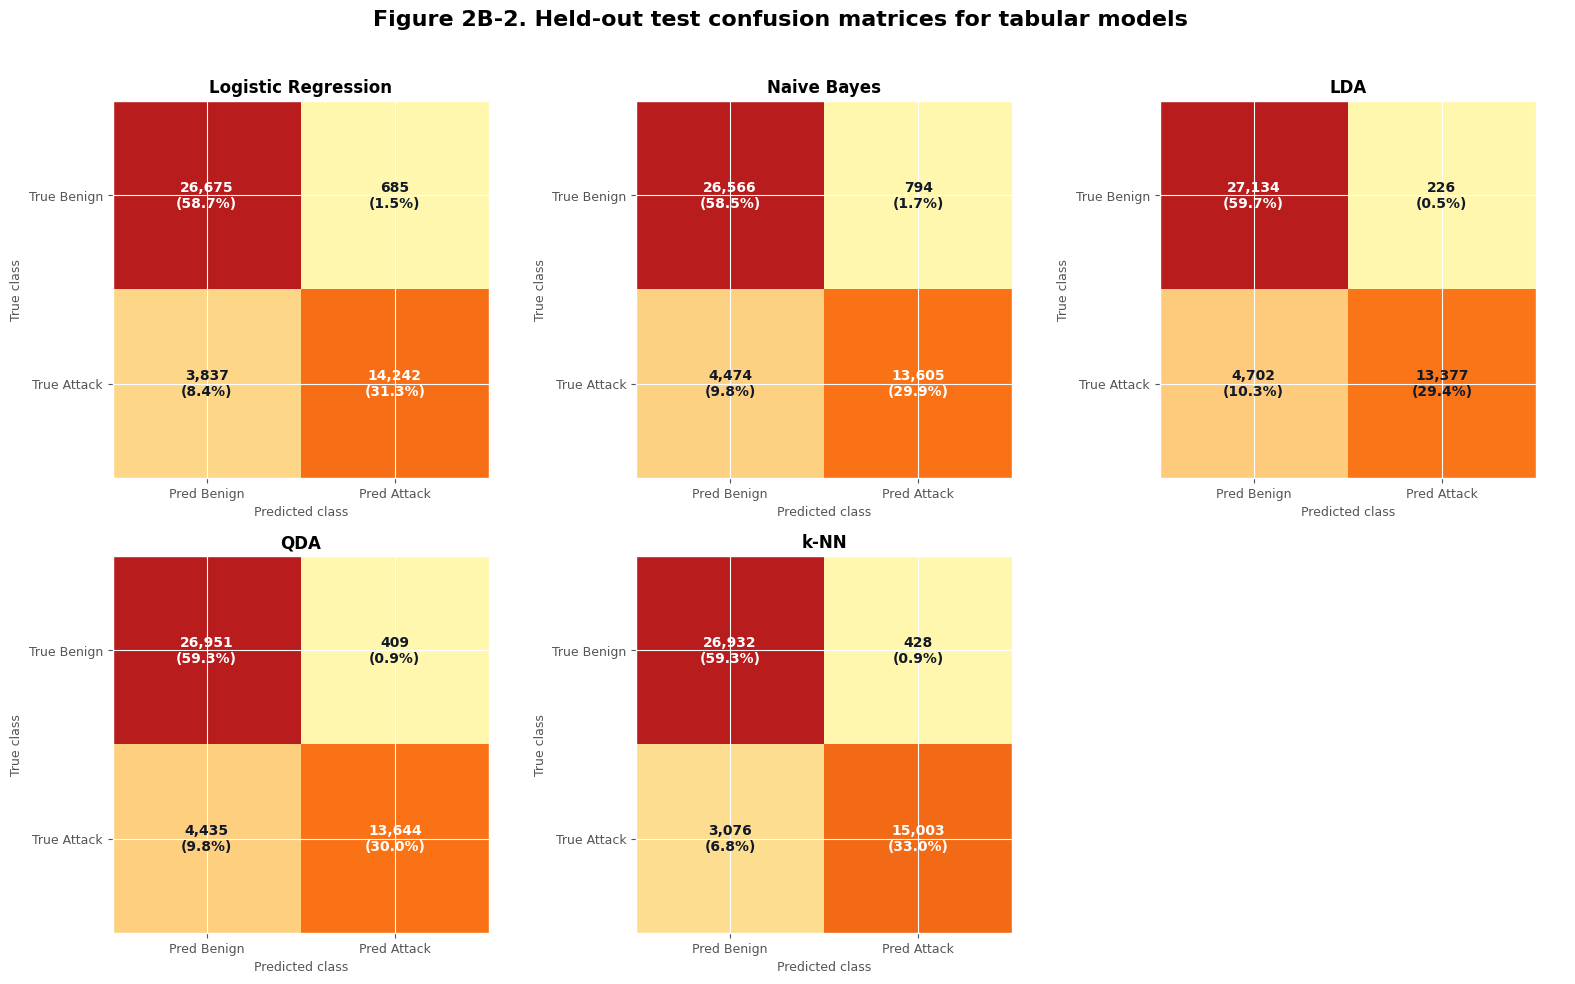

In [25]:
# Paper-friendly train/test table for tabular models only.
tabular_model_order = list(scaled_models.keys())

tabular_train_test_long_rows = []
for _, row in train_test_comparison_df.iterrows():
    model_name = row['model']
    if model_name not in tabular_model_order:
        continue
    tabular_train_test_long_rows.append({
        'model': model_name,
        'split': 'Train',
        'precision': row['train_precision'],
        'recall': row['train_recall'],
        'f1': row['train_f1'],
        'roc_auc': row['train_roc_auc'],
    })
    tabular_train_test_long_rows.append({
        'model': model_name,
        'split': 'Test',
        'precision': row['test_precision'],
        'recall': row['test_recall'],
        'f1': row['test_f1'],
        'roc_auc': row['test_roc_auc'],
    })

tabular_train_test_long_df = pd.DataFrame(tabular_train_test_long_rows)
tabular_train_test_long_df['model'] = pd.Categorical(
    tabular_train_test_long_df['model'],
    categories=tabular_model_order,
    ordered=True
)
tabular_train_test_long_df['split'] = pd.Categorical(
    tabular_train_test_long_df['split'],
    categories=['Train', 'Test'],
    ordered=True
)
tabular_train_test_long_df = tabular_train_test_long_df.sort_values(['model', 'split']).reset_index(drop=True)

print('Table 5B-2. Train/test comparison for tabular models only')
display(tabular_train_test_long_df.round(4))

# Combined held-out test confusion matrices for all tabular models.
from matplotlib.colors import LinearSegmentedColormap
import math

confusion_cmap = LinearSegmentedColormap.from_list(
    'yellow_orange_red_confusion',
    ['#fff7ad', '#f97316', '#b91c1c'],
    N=256
)

def plot_test_confusion_compact(ax, cm, title):
    im = ax.imshow(cm, cmap=confusion_cmap)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Attack'], fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Attack'], fontsize=9)
    ax.set_xlabel('Predicted class', fontsize=9)
    ax.set_ylabel('True class', fontsize=9)

    total = cm.sum()
    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(2):
        for j in range(2):
            count = int(cm[i, j])
            pct = (count / total * 100) if total else 0
            color = 'white' if cm[i, j] > threshold else '#111827'
            ax.text(
                j, i,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='center',
                color=color,
                fontsize=10,
                fontweight='bold'
            )
    return im

n_models = len(tabular_model_order)
n_cols = 3
n_rows = math.ceil(n_models / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.8 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, tabular_model_order):
    model = scaled_models[model_name]
    y_test_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_test_pred)
    plot_test_confusion_compact(ax, cm, model_name)

for ax in axes[n_models:]:
    ax.axis('off')

fig.suptitle(
    'Figure 2B-2. Held-out test confusion matrices for tabular models',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
fig.tight_layout()
plt.show()


### Figure 2B. Baseline F1 comparison across train, test, and 10-fold CV

This figure visualizes the most important metric from the unified table. If the training bar is much higher than the test or cross-validation bar, that can suggest overfitting. If the three bars are close, the model is more stable.


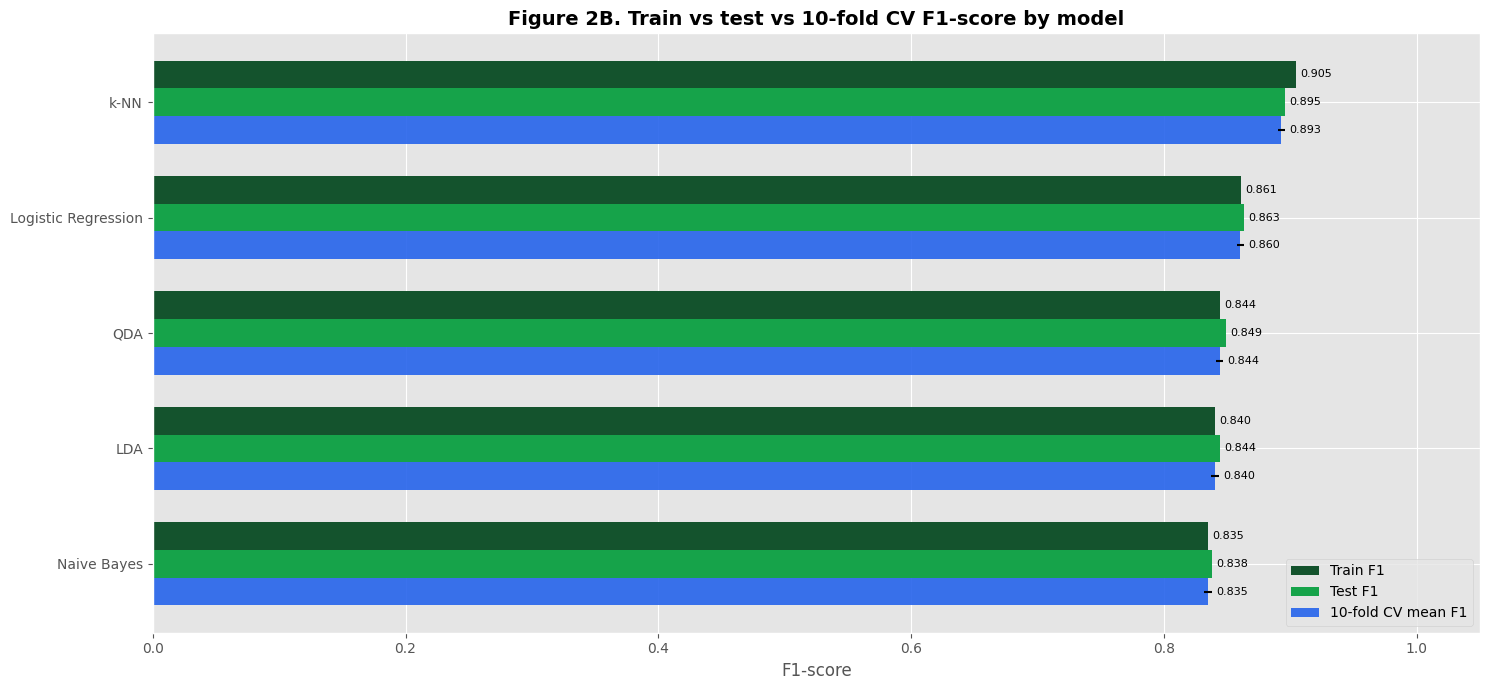

In [26]:
plot_df = baseline_unified_df.sort_values('test_f1', ascending=True)
y = np.arange(len(plot_df))
bar_h = 0.24

fig, ax = plt.subplots(figsize=(15, 7))
train_bars = ax.barh(y + bar_h, plot_df['train_f1'], height=bar_h, label='Train F1', color='#14532d')
test_bars = ax.barh(y, plot_df['test_f1'], height=bar_h, label='Test F1', color='#16a34a')
cv_bars = ax.barh(y - bar_h, plot_df['cv_f1_mean'], height=bar_h, xerr=plot_df['cv_f1_std'], label='10-fold CV mean F1', color='#2563eb', alpha=0.9)

ax.set_yticks(y)
ax.set_yticklabels(plot_df['model'])
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-score')
ax.set_title('Figure 2B. Train vs test vs 10-fold CV F1-score by model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

for bars in [train_bars, test_bars, cv_bars]:
    ax.bar_label(bars, labels=[f'{bar.get_width():.3f}' for bar in bars], padding=3, fontsize=8)

plt.tight_layout()
plt.show()


## <div style="color:#166534;">11C. Confusion matrices: train, test, and cross-validation</div>

A confusion matrix shows the type of mistakes each model makes. Here we compare three versions for every supervised baseline:

- **Train matrix**: how the model performs on the data it learned from.
- **Test matrix**: how the model performs on the held-out unseen test set.
- **10-fold CV matrix**: out-of-fold predictions on the training data, meaning every training row is predicted by a model that did not train on that row.

For intrusion detection, the most important cell is usually the **false negatives** cell: attack windows predicted as benign. Those are missed attacks.


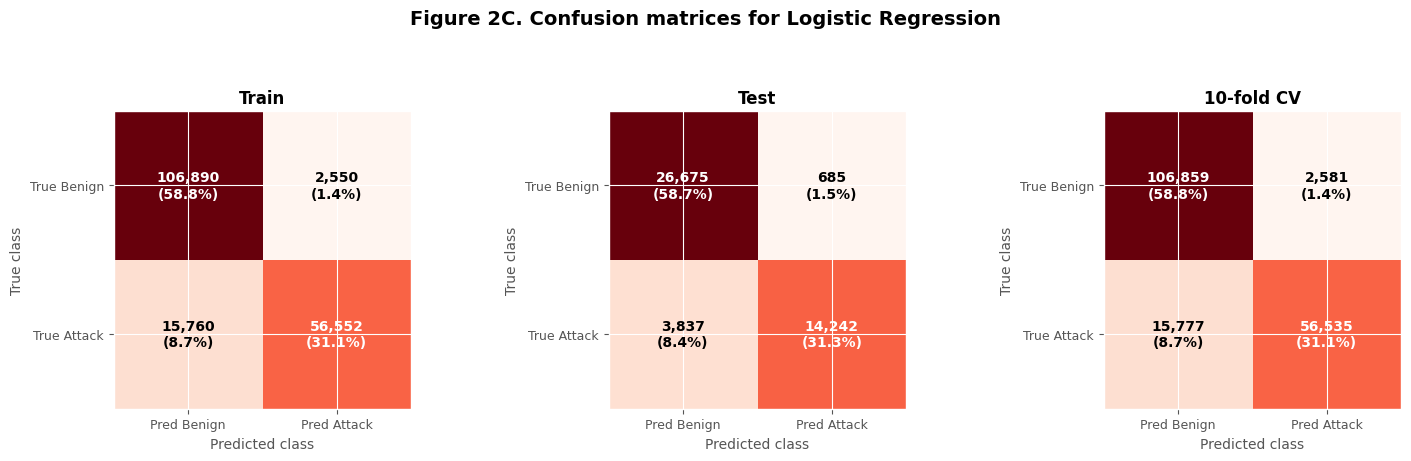

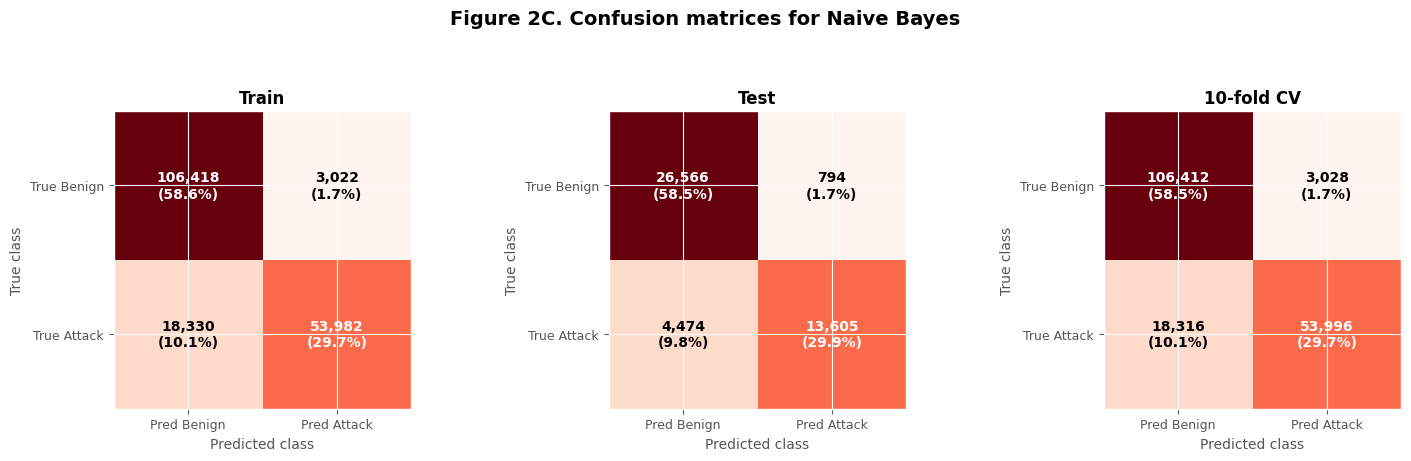

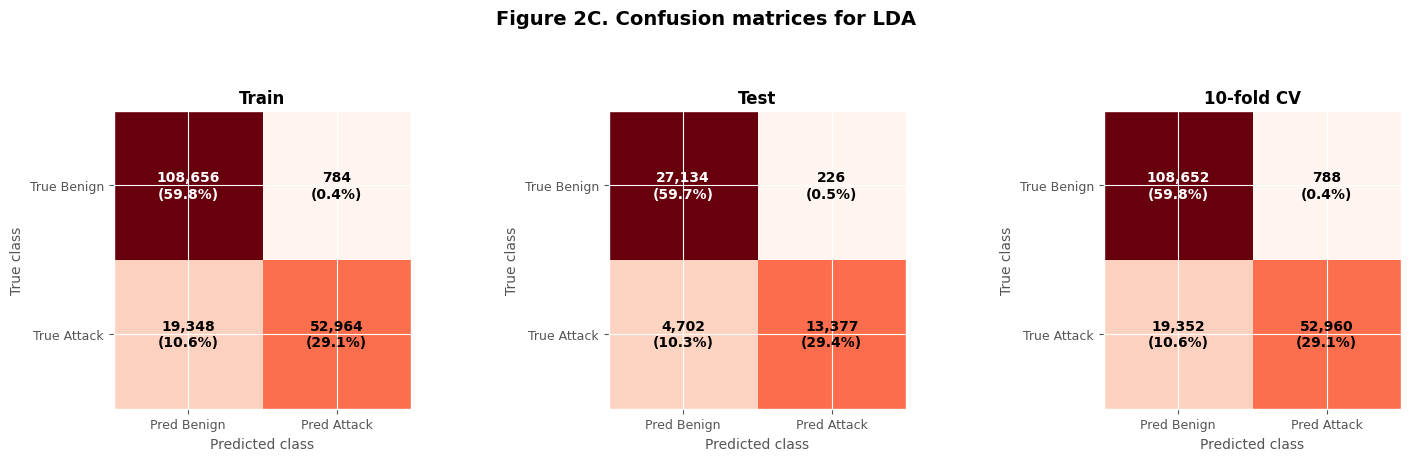

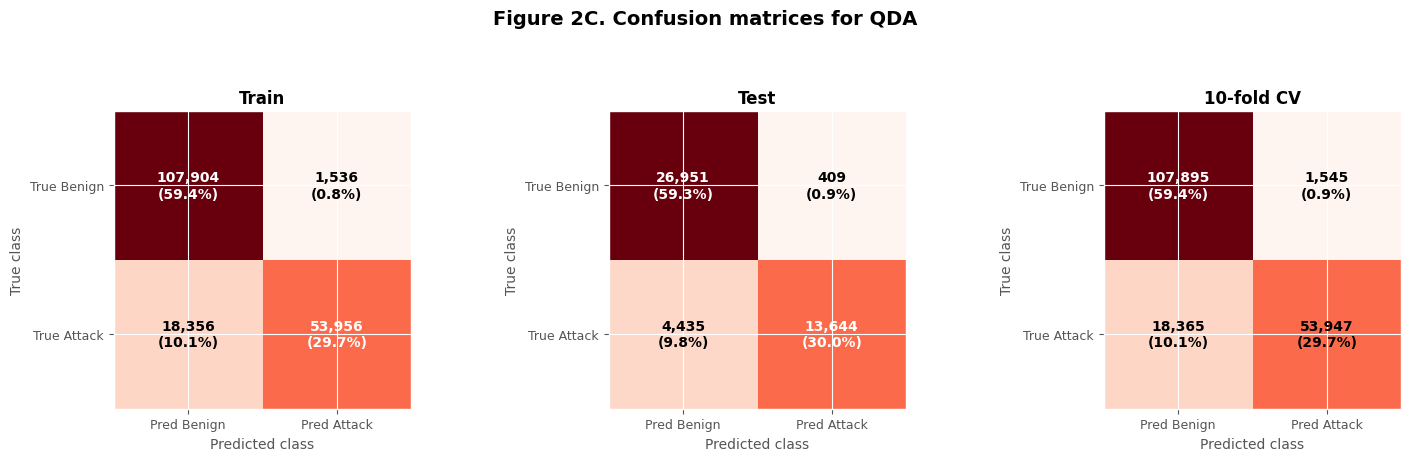

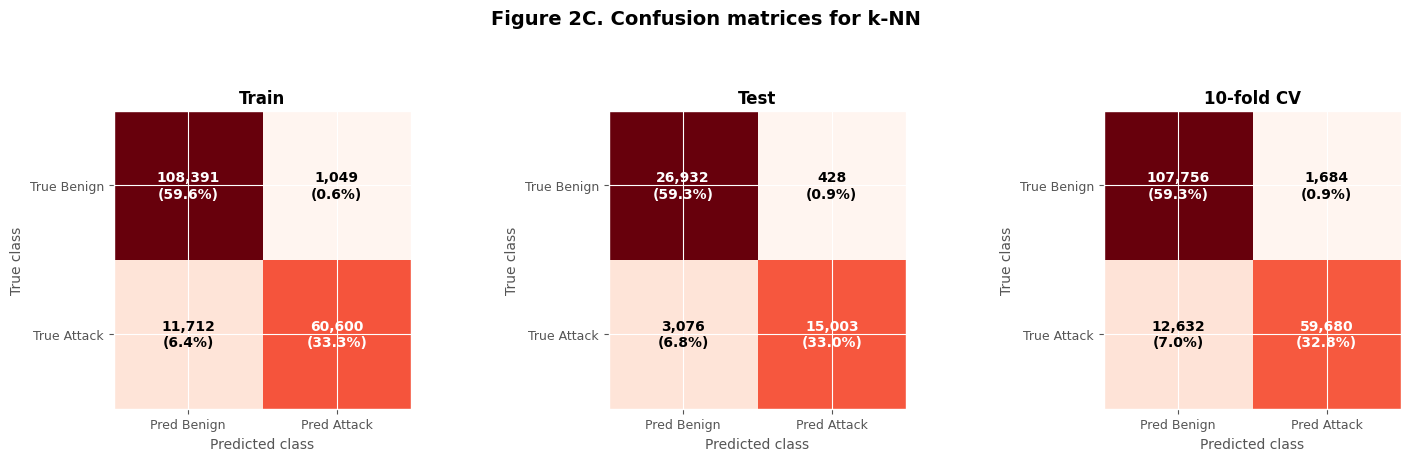

Table 5C. Confusion matrix counts by model and evaluation type


,model,evaluation,true_benign_pred_benign_TN,benign_pred_attack_FP,attack_pred_benign_FN,true_attack_pred_attack_TP,false_negative_pct_total,false_positive_pct_total,attack_recall,attack_precision
0,Logistic Regression,Train,106890,2550,15760,56552,0.0867,0.0140,0.7821,0.9569
1,Logistic Regression,Test,26675,685,3837,14242,0.0844,0.0151,0.7878,0.9541
2,Logistic Regression,10-fold CV,106859,2581,15777,56535,0.0868,0.0142,0.7818,0.9563
3,Naive Bayes,Train,106418,3022,18330,53982,0.1009,0.0166,0.7465,0.9470
4,Naive Bayes,Test,26566,794,4474,13605,0.0985,0.0175,0.7525,0.9449
5,Naive Bayes,10-fold CV,106412,3028,18316,53996,0.1008,0.0167,0.7467,0.9469
6,LDA,Train,108656,784,19348,52964,0.1065,0.0043,0.7324,0.9854
7,LDA,Test,27134,226,4702,13377,0.1035,0.0050,0.7399,0.9834
8,LDA,10-fold CV,108652,788,19352,52960,0.1065,0.0043,0.7324,0.9853
9,QDA,Train,107904,1536,18356,53956,0.1010,0.0085,0.7462,0.9723


In [27]:
# Confusion matrices for train, held-out test, and 10-fold cross-validation.
# The CV matrix uses out-of-fold predictions, so each row is predicted by a model that did not see it during fitting.

def plot_binary_confusion_with_percent(ax, cm, title):
    im = ax.imshow(cm, cmap='Reds')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Attack'], fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Attack'], fontsize=9)
    ax.set_xlabel('Predicted class', fontsize=10)
    ax.set_ylabel('True class', fontsize=10)

    total = cm.sum()
    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            pct = (count / total * 100) if total else 0
            color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(
                j, i,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='center',
                color=color,
                fontsize=10,
                fontweight='bold'
            )
    return im

cv_pred_cache = {}
for model_name, model in scaled_models.items():
    cv_pred_cache[model_name] = cross_val_predict(
        model,
        X_train_model,
        y_train_model,
        cv=cv,
        n_jobs=-1,
        method='predict'
    )

confusion_summary_rows = []

for model_name, model in scaled_models.items():
    matrices = {
        'Train': confusion_matrix(y_train_model, model.predict(X_train_model)),
        'Test': confusion_matrix(y_test, model.predict(X_test)),
        '10-fold CV': confusion_matrix(y_train_model, cv_pred_cache[model_name]),
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    fig.suptitle(f'Figure 2C. Confusion matrices for {model_name}', fontsize=14, fontweight='bold')

    for ax, (split_name, cm) in zip(axes, matrices.items()):
        plot_binary_confusion_with_percent(ax, cm, f'{split_name}')
        tn, fp, fn, tp = cm.ravel()
        total = cm.sum()
        confusion_summary_rows.append({
            'model': model_name,
            'evaluation': split_name,
            'true_benign_pred_benign_TN': int(tn),
            'benign_pred_attack_FP': int(fp),
            'attack_pred_benign_FN': int(fn),
            'true_attack_pred_attack_TP': int(tp),
            'false_negative_pct_total': fn / total if total else np.nan,
            'false_positive_pct_total': fp / total if total else np.nan,
            'attack_recall': tp / (tp + fn) if (tp + fn) else np.nan,
            'attack_precision': tp / (tp + fp) if (tp + fp) else np.nan,
        })

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

confusion_summary_df = pd.DataFrame(confusion_summary_rows)
print('Table 5C. Confusion matrix counts by model and evaluation type')
display(confusion_summary_df.round(4))


## <div style="color:#166534;">11D. Final supervised-baseline conclusion</div>

This section closes the classical supervised-learning analysis by identifying the strongest, second strongest, and weakest tabular classifiers under the common evaluation protocol.


In [28]:
best_test_model = baseline_unified_df.sort_values('test_f1', ascending=False).iloc[0]
best_cv_model = baseline_unified_df.sort_values('cv_f1_mean', ascending=False).iloc[0]
second_test_model = baseline_unified_df.sort_values('test_f1', ascending=False).iloc[1]
worst_test_model = baseline_unified_df.sort_values('test_f1', ascending=True).iloc[0]

stable_winner = best_test_model['model'] == best_cv_model['model']

baseline_conclusion = f"""
### Conclusion

After comparing training performance, held-out test performance, and 10-fold cross-validation, the strongest supervised baseline is **{best_test_model['model']}**. It achieved the highest held-out test F1-score (**{best_test_model['test_f1']:.4f}**) and test recall (**{best_test_model['test_recall']:.4f}**). Its 10-fold cross-validation F1-score was **{best_test_model['cv_f1_mean']:.4f}** with a standard deviation of **{best_test_model['cv_f1_std']:.4f}**.

The second strongest supervised baseline is **{second_test_model['model']}**, which is useful because it is more interpretable even though it does not outperform **{best_test_model['model']}**.

The weakest supervised baseline in this section is **{worst_test_model['model']}**, based on held-out test F1-score.

The most important takeaway is that **{best_test_model['model']}** provides the strongest classical reference result under the current protocol. {'The fact that the same model also ranks first under 10-fold cross-validation strengthens confidence that this result is stable, not just a lucky train/test split.' if stable_winner else 'Because the best test model and best cross-validation model differ, both rankings should be discussed carefully.'}
"""

display(Markdown(baseline_conclusion))



### Conclusion

After comparing training performance, held-out test performance, and 10-fold cross-validation, the strongest supervised baseline is **k-NN**. It achieved the highest held-out test F1-score (**0.8954**) and test recall (**0.8299**). Its 10-fold cross-validation F1-score was **0.8929** with a standard deviation of **0.0029**.

The second strongest supervised baseline is **Logistic Regression**, which is useful because it is more interpretable even though it does not outperform **k-NN**.

The weakest supervised baseline in this section is **Naive Bayes**, based on held-out test F1-score.

The most important takeaway is that **k-NN** provides the strongest classical reference result under the current protocol. The fact that the same model also ranks first under 10-fold cross-validation strengthens confidence that this result is stable, not just a lucky train/test split.
